# Expression Quantitative Trait Loci (eQTL) Analysis Tutorial

## Introduction

This comprehensive tutorial introduces **expression Quantitative Trait Loci (eQTL) analysis**, a powerful approach in statistical genetics that identifies genetic variants associated with gene expression levels. eQTL mapping bridges genotype and phenotype by revealing how DNA sequence variation influences gene regulation.

### What are eQTLs?

An **eQTL** (expression Quantitative Trait Locus) is a genomic region containing genetic variants that influence the expression level of one or more genes. eQTLs can be classified as:

- **cis-eQTLs**: Variants located near the gene they regulate (typically within 1 Mb), often affecting local regulatory elements
- **trans-eQTLs**: Variants located far from or on different chromosomes than the genes they regulate, typically acting through intermediate factors

### Tutorial Overview

This tutorial covers the complete eQTL analysis workflow:

1. **Simple SNP-Gene Expression Associations**: Understanding basic relationships between genetic variants and gene expression
2. **Handling Confounding Variation**: Incorporating clinical and technical covariates to control for confounders
3. **Principal Components Analysis**: Using dimensionality reduction to capture hidden technical variation
4. **Genome-Wide eQTL Analysis**: Scaling up to test thousands of variant-gene pairs

### Dataset Description

We work with the **ASD (Autism Spectrum Disorder) multiomics dataset** containing:
- **300 individuals** (cases and controls)
- **50 SNPs** (Single Nucleotide Polymorphisms)
- **100 genes** with expression measurements (ASD-relevant genes)
- **Clinical covariates**: Age, Sex, ASD diagnosis, IQ, ADOS scores, behavioral measures
- **Technical covariates**: 20 latent variables capturing batch/technical effects
- Genotypes encoded as 0, 1, or 2 (copies of the alternative allele)

### Prerequisites

This tutorial requires:
- Python 3.7+
- pandas, numpy, matplotlib, seaborn, scipy, scikit-learn, statsmodels
- Basic understanding of linear regression and statistical testing

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests
import warnings
warnings.filterwarnings('ignore')

# Set visualization parameters for publication-quality figures
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_context("notebook", font_scale=1.1)
sns.set_palette("Set2")

# Configure pandas display options
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 4)

print("\u2713 All libraries imported successfully")
print(f"\u2713 Pandas version: {pd.__version__}")
print(f"\u2713 NumPy version: {np.__version__}")

✓ All libraries imported successfully
✓ Pandas version: 3.0.0
✓ NumPy version: 2.4.2


---
## Section 1: Simple SNP-Gene Expression Associations

In this section, we begin with fundamental eQTL concepts by examining associations between individual SNPs and gene expression levels. We will:

1. Load and explore genotype and expression data
2. Calculate Minor Allele Frequencies (MAF)
3. Visualize expression patterns across genotype groups
4. Perform linear regression to quantify SNP effects

### Learning Objectives
- Understand the structure of eQTL data
- Interpret genotype encoding (0, 1, 2)
- Visualize genotype-expression relationships
- Estimate effect sizes with confidence intervals

### 1.1 Loading and Exploring the Data

In [2]:
# Load genotype data
# Each row represents an individual, columns represent SNPs
# Values: 0 (homozygous reference), 1 (heterozygous), 2 (homozygous alternative)
geno = pd.read_csv('../data/ASD_dataset/ASD_genotypes.csv')

# Load gene expression data
# Each row represents an individual, columns represent genes
# Values: raw RNA-seq counts (will be normalized in the next section)
expr = pd.read_csv('../data/ASD_dataset/ASD_expression.csv')

print("=" * 70)
print("GENOTYPE DATA")
print("=" * 70)
print(f"Dimensions: {geno.shape[0]} individuals × {geno.shape[1]-1} SNPs")
print(f"\nFirst 5 rows:")
print(geno.head())

print("\n" + "=" * 70)
print("EXPRESSION DATA (raw counts)")
print("=" * 70)
print(f"Dimensions: {expr.shape[0]} individuals × {expr.shape[1]-1} genes")
print(f"\nFirst 5 rows:")
print(expr.head())

# Verify data integrity
assert geno.shape[0] == expr.shape[0], "Sample size mismatch between genotype and expression data"
assert all(geno['sample'] == expr['sample']), "Sample IDs do not match between datasets"
print("\n✓ Data integrity verified: Sample IDs match across datasets")

GENOTYPE DATA
Dimensions: 300 individuals × 50 SNPs

First 5 rows:
     sample  snp_1  snp_2  snp_3  snp_4  snp_5  snp_6  snp_7  snp_8  snp_9  \
0  sample_1      0      0      0      0      1      0      0      0      2   
1  sample_2      0      0      0      0      0      0      0      0      2   
2  sample_3      0      0      0      0      0      0      0      0      1   
3  sample_4      0      0      0      0      0      0      1      1      0   
4  sample_5      0      0      0      0      0      0      0      1      0   

   snp_10  snp_11  snp_12  snp_13  snp_14  snp_15  snp_16  snp_17  snp_18  \
0       2       1       1       1       0       1       1       0       0   
1       2       1       1       0       1       1       1       0       1   
2       2       0       1       0       0       1       1       0       0   
3       1       2       1       0       0       1       1       0       0   
4       1       0       0       0       0       0       2       0       0   

 

### 1.2 Expression Normalization

Raw RNA-seq counts are **not suitable** for direct eQTL regression because:

- **Heteroscedastic variance**: highly expressed genes (e.g., SHANK3 ~10,000) have much larger variance than lowly expressed genes (e.g., PTEN ~0-8), violating the linear model's constant-variance assumption
- **Right-skewed distributions**: count data follows Poisson/negative-binomial distributions, not Gaussian
- **Incomparable scales**: effect sizes depend on each gene's dynamic range, making cross-gene comparisons meaningless

**Solution: Inverse Normal Transformation (INT)** per gene — ranks samples and maps to quantiles of a standard normal distribution (Blom's method). After INT:
- Every gene has mean = 0, std = 1, and exactly Gaussian shape
- Linear model assumptions (normality, homoscedasticity) are satisfied
- Effect sizes are comparable across genes

This is the standard in production eQTL pipelines (GTEx, eQTL Catalogue, eQTLGen).

EXPRESSION NORMALIZATION

Before normalization (raw counts):
  Range: [0, 42755]
  Mean of gene means: 745.5
  Example (SHANK3): mean=12719, std=4843
  Example (PTEN):   mean=1.58, std=2.18

After inverse normal transformation:
  Range: [-2.866, 2.866]
  Mean of gene means: 0.002669 (approx 0)
  Mean of gene stds:  0.988236 (approx 1)


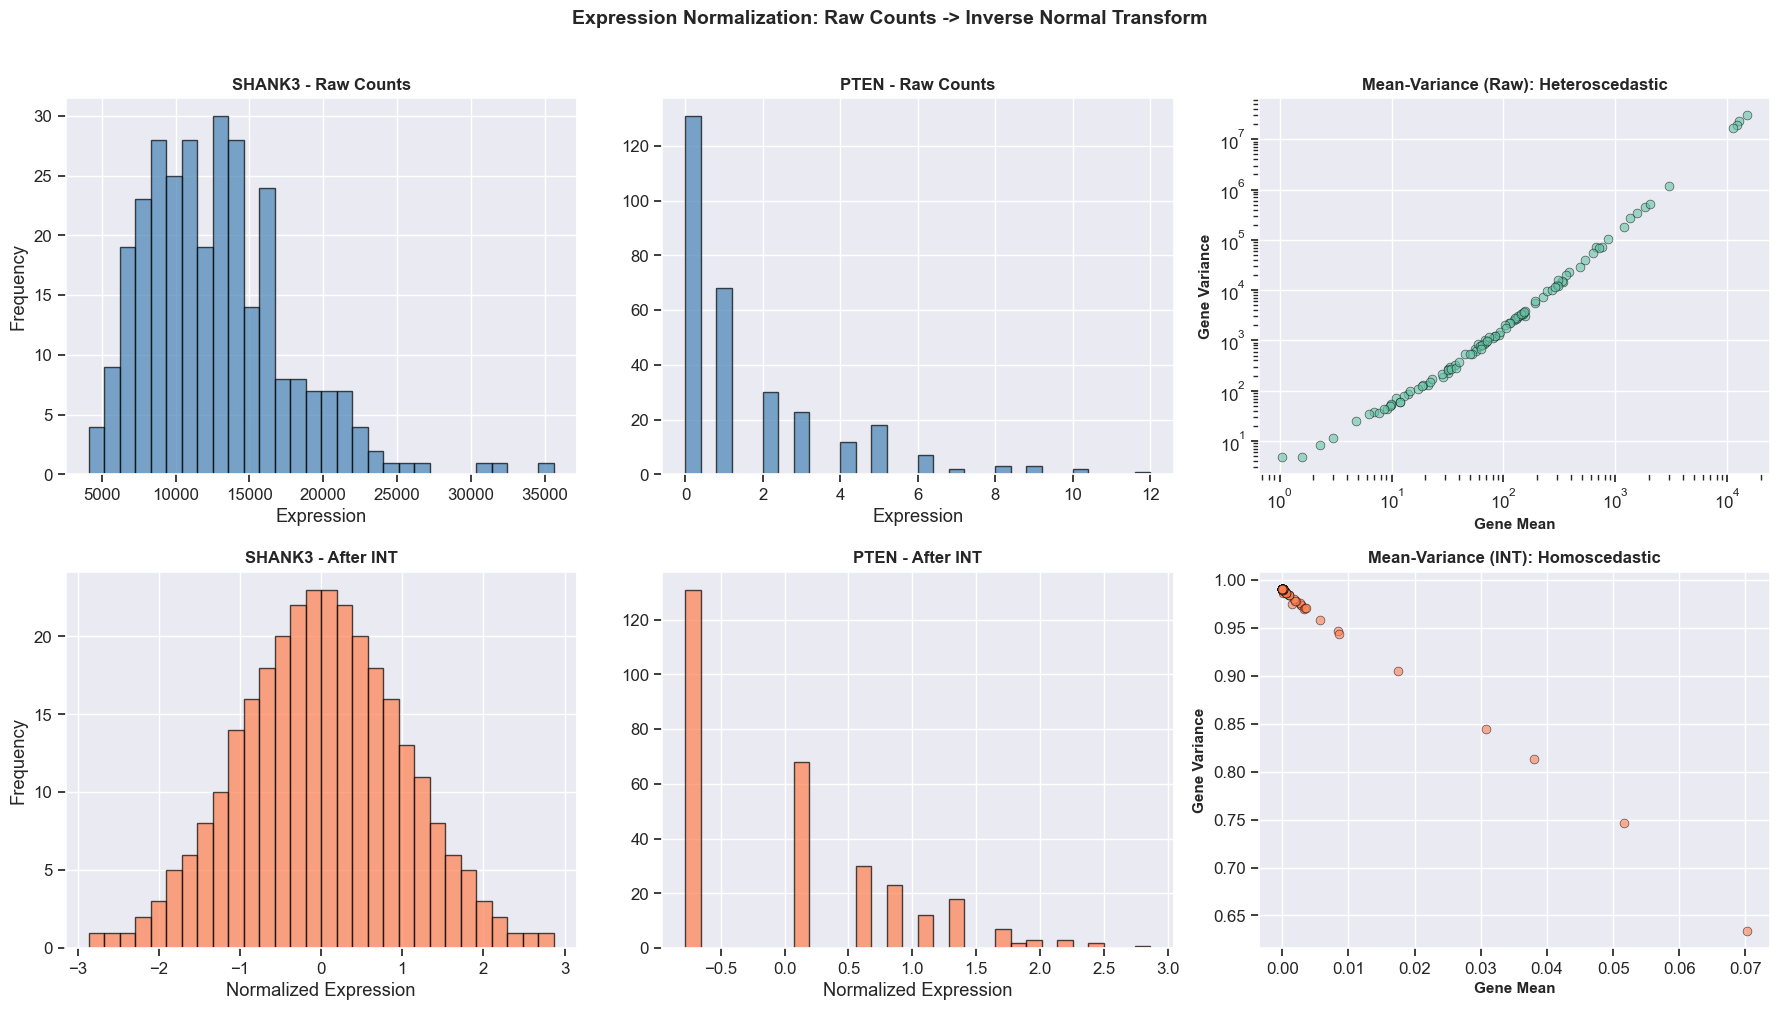


✓ Expression normalized via inverse normal transform (Blom's method)
  All downstream analyses will use normalized expression values


In [3]:
from scipy.stats import rankdata, norm

print("=" * 70)
print("EXPRESSION NORMALIZATION")
print("=" * 70)

# Preserve sample column
sample_ids = expr['sample']
expr_raw = expr.iloc[:, 1:].copy()

print(f"\nBefore normalization (raw counts):")
print(f"  Range: [{expr_raw.min().min():.0f}, {expr_raw.max().max():.0f}]")
print(f"  Mean of gene means: {expr_raw.mean().mean():.1f}")
print(f"  Example (SHANK3): mean={expr_raw['SHANK3'].mean():.0f}, std={expr_raw['SHANK3'].std():.0f}")
print(f"  Example (PTEN):   mean={expr_raw['PTEN'].mean():.2f}, std={expr_raw['PTEN'].std():.2f}")

# Inverse Normal Transformation (INT) per gene
# Rank each gene across samples, then map ranks to quantiles of N(0,1)
# Ranks are invariant to monotonic transforms, so log2 beforehand would be redundant
def inverse_normal_transform(x):
    """Rank-based inverse normal transformation (Blom's method)."""
    n = len(x)
    ranks = rankdata(x)
    # Blom's formula: quantiles at (rank - 3/8) / (n + 1/4)
    quantiles = (ranks - 3/8) / (n + 1/4)
    return norm.ppf(quantiles)

expr_int = expr_raw.apply(inverse_normal_transform, axis=0)

print(f"\nAfter inverse normal transformation:")
print(f"  Range: [{expr_int.min().min():.3f}, {expr_int.max().max():.3f}]")
print(f"  Mean of gene means: {expr_int.mean().mean():.6f} (approx 0)")
print(f"  Mean of gene stds:  {expr_int.std().mean():.6f} (approx 1)")

# Reconstruct the expr DataFrame with normalized values
expr = pd.concat([sample_ids, expr_int], axis=1)

# Visualize before vs after
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Row 1: Before (raw counts)
ax = axes[0, 0]
ax.hist(expr_raw['SHANK3'], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
ax.set_title('SHANK3 - Raw Counts', fontsize=12, fontweight='bold')
ax.set_xlabel('Expression')
ax.set_ylabel('Frequency')

ax = axes[0, 1]
ax.hist(expr_raw['PTEN'], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
ax.set_title('PTEN - Raw Counts', fontsize=12, fontweight='bold')
ax.set_xlabel('Expression')

ax = axes[0, 2]
# Show variance vs mean relationship (raw)
gene_means_raw = expr_raw.mean()
gene_vars_raw = expr_raw.var()
ax.scatter(gene_means_raw, gene_vars_raw, alpha=0.6, s=40, edgecolors='black', linewidth=0.5)
ax.set_xlabel('Gene Mean', fontsize=11, fontweight='bold')
ax.set_ylabel('Gene Variance', fontsize=11, fontweight='bold')
ax.set_title('Mean-Variance (Raw): Heteroscedastic', fontsize=12, fontweight='bold')
ax.set_xscale('log')
ax.set_yscale('log')

# Row 2: After normalization
ax = axes[1, 0]
ax.hist(expr_int['SHANK3'], bins=30, edgecolor='black', alpha=0.7, color='coral')
ax.set_title('SHANK3 - After INT', fontsize=12, fontweight='bold')
ax.set_xlabel('Normalized Expression')
ax.set_ylabel('Frequency')

ax = axes[1, 1]
ax.hist(expr_int['PTEN'], bins=30, edgecolor='black', alpha=0.7, color='coral')
ax.set_title('PTEN - After INT', fontsize=12, fontweight='bold')
ax.set_xlabel('Normalized Expression')

ax = axes[1, 2]
gene_means_int = expr_int.mean()
gene_vars_int = expr_int.var()
ax.scatter(gene_means_int, gene_vars_int, alpha=0.6, s=40, edgecolors='black', linewidth=0.5, color='coral')
ax.set_xlabel('Gene Mean', fontsize=11, fontweight='bold')
ax.set_ylabel('Gene Variance', fontsize=11, fontweight='bold')
ax.set_title('Mean-Variance (INT): Homoscedastic', fontsize=12, fontweight='bold')

plt.suptitle('Expression Normalization: Raw Counts -> Inverse Normal Transform',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("\n✓ Expression normalized via inverse normal transform (Blom's method)")
print("  All downstream analyses will use normalized expression values")


### 1.3 Calculating Minor Allele Frequencies (MAF)

The **Minor Allele Frequency (MAF)** represents the frequency of the less common allele in a population. MAF is critical in genetics because:

- It determines statistical power to detect associations
- Rare variants (MAF < 0.05) require larger sample sizes
- Common variants (MAF > 0.05) are more reliably tested

**Calculation**: Since genotypes are coded as 0, 1, or 2 (allele counts), the allele frequency is simply the mean genotype divided by 2.

MINOR ALLELE FREQUENCY ANALYSIS
   SNP  Allele_Frequency    MAF Minor_Allele
 snp_1            0.0067 0.0067          Alt
 snp_2            0.0300 0.0300          Alt
 snp_3            0.0200 0.0200          Alt
 snp_4            0.0650 0.0650          Alt
 snp_5            0.0467 0.0467          Alt
 snp_6            0.1267 0.1267          Alt
 snp_7            0.1717 0.1717          Alt
 snp_8            0.2983 0.2983          Alt
 snp_9            0.3900 0.3900          Alt
snp_10            0.5117 0.4883          Ref
snp_11            0.2600 0.2600          Alt
snp_12            0.3183 0.3183          Alt
snp_13            0.1667 0.1667          Alt
snp_14            0.2933 0.2933          Alt
snp_15            0.3283 0.3283          Alt
snp_16            0.2033 0.2033          Alt
snp_17            0.2150 0.2150          Alt
snp_18            0.3050 0.3050          Alt
snp_19            0.1700 0.1700          Alt
snp_20            0.1700 0.1700          Alt
snp_21            0.150

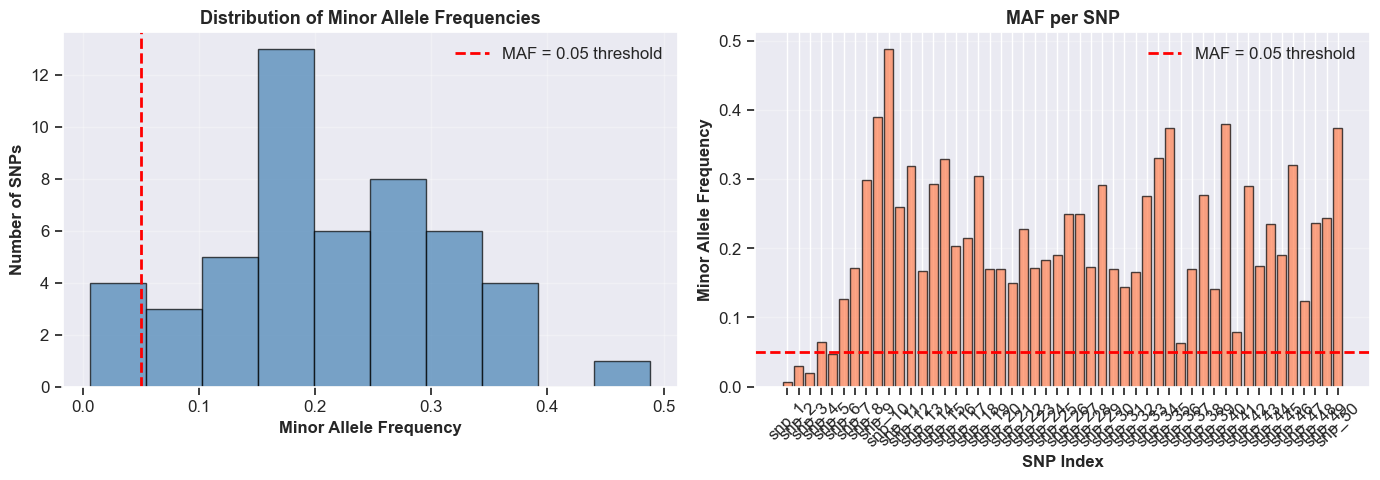


✓ MAF Statistics:
  - Mean MAF: 0.2143
  - Median MAF: 0.1967
  - Range: [0.0067, 0.4883]
  - SNPs with MAF > 0.05: 46/50


In [4]:
# Extract genotype matrix (excluding sample ID column)
geno_matrix = geno.iloc[:, 1:]

# Calculate allele frequency for each SNP
# Formula: mean(genotype) / 2, since genotypes are 0, 1, or 2
allele_freq = geno_matrix.mean() / 2

# Calculate Minor Allele Frequency (MAF)
# MAF is the minimum of allele frequency and its complement
maf = np.minimum(allele_freq, 1 - allele_freq)

# Create a summary DataFrame
maf_summary = pd.DataFrame({
    'SNP': maf.index,
    'Allele_Frequency': allele_freq.values,
    'MAF': maf.values,
    'Minor_Allele': ['Alt' if af <= 0.5 else 'Ref' for af in allele_freq.values]
})

print("=" * 70)
print("MINOR ALLELE FREQUENCY ANALYSIS")
print("=" * 70)
print(maf_summary.to_string(index=False))

# Visualize MAF distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of MAF
ax1.hist(maf.values, bins=10, edgecolor='black', alpha=0.7, color='steelblue')
ax1.axvline(0.05, color='red', linestyle='--', linewidth=2, label='MAF = 0.05 threshold')
ax1.set_xlabel('Minor Allele Frequency', fontsize=12, fontweight='bold')
ax1.set_ylabel('Number of SNPs', fontsize=12, fontweight='bold')
ax1.set_title('Distribution of Minor Allele Frequencies', fontsize=13, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Bar plot of MAF for each SNP
ax2.bar(range(len(maf)), maf.values, edgecolor='black', alpha=0.7, color='coral')
ax2.axhline(0.05, color='red', linestyle='--', linewidth=2, label='MAF = 0.05 threshold')
ax2.set_xlabel('SNP Index', fontsize=12, fontweight='bold')
ax2.set_ylabel('Minor Allele Frequency', fontsize=12, fontweight='bold')
ax2.set_title('MAF per SNP', fontsize=13, fontweight='bold')
ax2.set_xticks(range(len(maf)))
ax2.set_xticklabels(maf.index, rotation=45)
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\n\u2713 MAF Statistics:")
print(f"  - Mean MAF: {maf.mean():.4f}")
print(f"  - Median MAF: {maf.median():.4f}")
print(f"  - Range: [{maf.min():.4f}, {maf.max():.4f}]")
print(f"  - SNPs with MAF > 0.05: {(maf > 0.05).sum()}/{len(maf)}")

### 1.4 Visualizing Expression Levels by Genotype

Visualization is essential for eQTL discovery. Box plots and violin plots effectively show:
- Central tendency (median) of expression for each genotype group
- Variability (interquartile range) within groups
- Potential outliers
- Dose-response relationships (additive genetic effects)

We'll create a comprehensive visualization showing expression distributions across all SNP-gene combinations.

DATA TRANSFORMATION FOR VISUALIZATION
Creating plots for NTF3 across all SNPs...


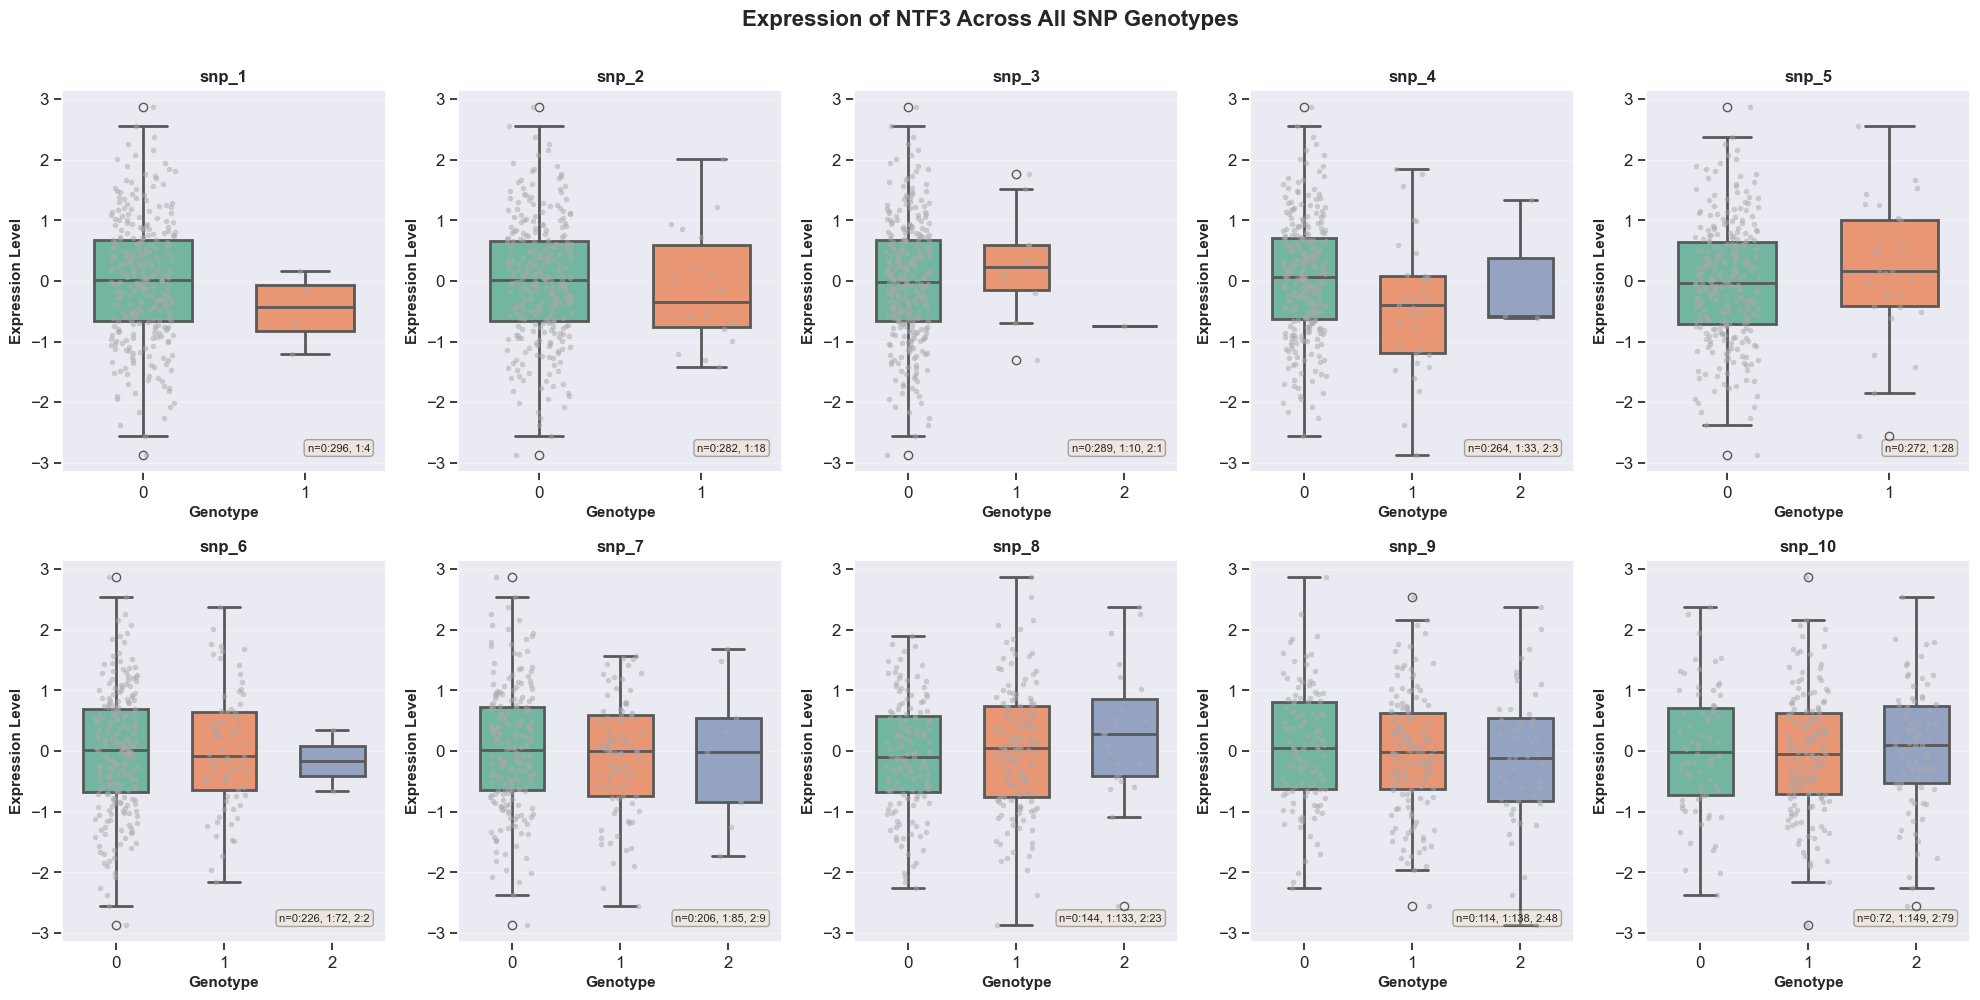


✓ Visualization complete for NTF3 across all SNPs

Interpretation Guide:
  - Box shows interquartile range (25th to 75th percentile)
  - Line in box represents median expression
  - Whiskers extend to 1.5 × IQR from quartiles
  - Individual points show actual observations
  - Sample sizes shown in bottom-right (genotype:count)
  - Look for trends: expression increasing/decreasing with genotype dosage


In [5]:
# Reshape data to long format for visualization
# This transformation allows us to plot SNP-expression relationships

# For visualization, we'll focus on one gene and show it across all SNPs
gene_to_plot = 'NTF3'

print("=" * 70)
print("DATA TRANSFORMATION FOR VISUALIZATION")
print("=" * 70)
print(f"Creating plots for {gene_to_plot} across all SNPs...")

# Set up the figure
fig, axes = plt.subplots(2, 5, figsize=(20, 10))
axes = axes.flatten()

# Create box plots for each SNP
for idx, snp in enumerate(geno.columns[1:][:10]):
    ax = axes[idx]
    
    # Create a dataframe for this specific SNP-gene pair
    plot_data = pd.DataFrame({
        'genotype': geno[snp].astype('category'),
        'expression': expr[gene_to_plot]
    })
    
    # Create box plot with overlaid data points
    sns.boxplot(x='genotype', y='expression', data=plot_data, ax=ax, 
                palette='Set2', width=0.6, linewidth=2)
    
    # Add jittered points to show individual observations
    sns.stripplot(x='genotype', y='expression', data=plot_data, ax=ax,
                  color='darkgrey', alpha=0.5, size=4, jitter=0.2)
    
    ax.set_title(f'{snp}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Genotype', fontsize=11, fontweight='bold')
    ax.set_ylabel('Expression Level', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add sample size annotation
    genotype_counts = plot_data['genotype'].value_counts().sort_index()
    count_text = ', '.join([f"{g}:{c}" for g, c in genotype_counts.items()])
    ax.text(0.95, 0.05, f'n={count_text}', transform=ax.transAxes, 
            fontsize=8, verticalalignment='bottom', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.suptitle(f'Expression of {gene_to_plot} Across All SNP Genotypes', 
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print(f"\n\u2713 Visualization complete for {gene_to_plot} across all SNPs")
print(f"\nInterpretation Guide:")
print(f"  - Box shows interquartile range (25th to 75th percentile)")
print(f"  - Line in box represents median expression")
print(f"  - Whiskers extend to 1.5 × IQR from quartiles")
print(f"  - Individual points show actual observations")
print(f"  - Sample sizes shown in bottom-right (genotype:count)")
print(f"  - Look for trends: expression increasing/decreasing with genotype dosage")

### 1.5 Linear Regression Analysis for SNP Effects

Linear regression is the foundation of eQTL mapping. For each SNP-gene pair, we fit the model:

$$
\text{Expression}_i = \beta_0 + \beta_1 \times \text{Genotype}_i + \epsilon_i
$$

Where:
- $\beta_0$ is the intercept (baseline expression for genotype = 0)
- $\beta_1$ is the **SNP effect** (change in expression per copy of the alternative allele)
- $\epsilon_i$ is the error term (unexplained variation)

Key metrics we extract:
- **Effect size (β)**: Magnitude of association
- **95% Confidence Interval**: Range of plausible effect sizes
- **p-value**: Statistical significance
- **R²**: Proportion of variance explained

In [6]:
def perform_eqtl_regression(genotype, expression, snp_name, gene_name):
    """
    Perform linear regression for a single SNP-gene pair.
    
    Parameters:
    -----------
    genotype : array-like
        Genotype values (0, 1, 2) for all individuals
    expression : array-like
        Expression values for all individuals
    snp_name : str
        Name of the SNP
    gene_name : str
        Name of the gene
    
    Returns:
    --------
    dict : Dictionary containing regression results
    """
    # Add intercept to the model
    X = sm.add_constant(genotype)  # Add column of ones
    y = expression
    
    # Ordinary Least Squares is the standard method used to estimate parameters in linear regression models
    model = sm.OLS(y, X).fit()  # computes coefficients by minimizing squared residual error
    
    # Extract results
    beta = model.params[1]  # SNP effect (slope)
    se = model.bse[1]  # Standard error
    ci_lower, ci_upper = model.conf_int()[1]  # 95% confidence interval
    pval = model.pvalues[1]  # p-value
    rsquared = model.rsquared  # R-squared
    
    return {
        'SNP': snp_name,
        'Gene': gene_name,
        'Beta': beta,  # Effect size beta1 - slope
        'SE': se,
        'CI_Lower': ci_lower,
        'CI_Upper': ci_upper,
        'P_value': pval,
        'R_squared': rsquared
    }

# Perform regression for one SNP-gene pair as an example
example_snp = 'snp_1'
example_gene = 'NTF3'

result = perform_eqtl_regression(
    genotype=geno[example_snp].values,
    expression=expr[example_gene].values,
    snp_name=example_snp,
    gene_name=example_gene
)

print("=" * 70)
print(f"EXAMPLE eQTL REGRESSION: {example_snp} vs {example_gene}")
print("=" * 70)
print(f"Effect size (β):          {result['Beta']:.4f}")
print(f"Standard error:           {result['SE']:.4f}")
print(f"95% CI:                   [{result['CI_Lower']:.4f}, {result['CI_Upper']:.4f}]")
print(f"P-value:                  {result['P_value']:.4e}")
print(f"R² (variance explained):  {result['R_squared']:.4f}")

# Interpretation
print(f"\n{'='*70}")
print("INTERPRETATION")
print(f"{'='*70}")
if result['P_value'] < 0.05:
    direction = "increases" if result['Beta'] > 0 else "decreases"
    print(f"\u2713 SIGNIFICANT ASSOCIATION DETECTED (p < 0.05)")
    print(f"\nEach copy of the alternative allele at {example_snp}")
    print(f"{direction} expression of {example_gene} by {abs(result['Beta']):.4f} units.")
    print(f"\nThis SNP explains {result['R_squared']*100:.2f}% of variance in {example_gene} expression.")
else:
    print(f"✗ No significant association detected (p = {result['P_value']:.4f})")

# Now run regression for ALL SNP-gene pairs
print(f"\n{'='*70}")
print("COMPREHENSIVE eQTL ANALYSIS: ALL SNP-GENE PAIRS")
print(f"{'='*70}")

# Test all combinations of SNPs and genotypes
all_results = []
for snp in geno.columns[1:]:
    for gene in expr.columns[1:]:
        result = perform_eqtl_regression(
            genotype=geno[snp].values,
            expression=expr[gene].values,
            snp_name=snp,
            gene_name=gene
        )
        all_results.append(result)

# Convert to DataFrame
eqtl_results = pd.DataFrame(all_results)

# Add significance indicator
eqtl_results['Significant'] = eqtl_results['P_value'] < 0.05

# Sort by p-value
eqtl_results = eqtl_results.sort_values('P_value')

print(f"\nTotal tests performed: {len(eqtl_results)}")
print(f"Significant associations (p < 0.05): {eqtl_results['Significant'].sum()}")
print(f"\nTop 10 most significant associations:\n")
print(eqtl_results.head(10).to_string(index=False))

EXAMPLE eQTL REGRESSION: snp_1 vs NTF3
Effect size (β):          -0.4769
Standard error:           0.5012
95% CI:                   [-1.4632, 0.5095]
P-value:                  3.4215e-01
R² (variance explained):  0.0030

INTERPRETATION
✗ No significant association detected (p = 0.3422)

COMPREHENSIVE eQTL ANALYSIS: ALL SNP-GENE PAIRS



Total tests performed: 5000
Significant associations (p < 0.05): 173

Top 10 most significant associations:

   SNP    Gene    Beta     SE  CI_Lower  CI_Upper  P_value  R_squared  Significant
 snp_4 CACNA1B -0.5277 0.1545   -0.8317   -0.2237   0.0007     0.0377         True
snp_28   CREB1 -0.3001 0.0947   -0.4865   -0.1136   0.0017     0.0326         True
snp_48    MBD5 -0.3032 0.0958   -0.4918   -0.1147   0.0017     0.0325         True
snp_48   KCNQ2 -0.3022 0.0958   -0.4908   -0.1136   0.0018     0.0323         True
snp_30   NCAM1  0.3404 0.1102    0.1236    0.5572   0.0022     0.0310         True
snp_13  GABRG2 -0.3171 0.1031   -0.5200   -0.1142   0.0023     0.0308         True
snp_40    SYN1 -0.2375 0.0775   -0.3899   -0.0850   0.0024     0.0306         True
 snp_4 NEUROD1 -0.4751 0.1554   -0.7808   -0.1693   0.0024     0.0304         True
snp_48   DSCAM -0.2828 0.0938   -0.4674   -0.0982   0.0028     0.0296         True
snp_39   ASH1L  0.3424 0.1142    0.1177    0.5672   0.0029  

### 1.6 Visualizing Regression Results

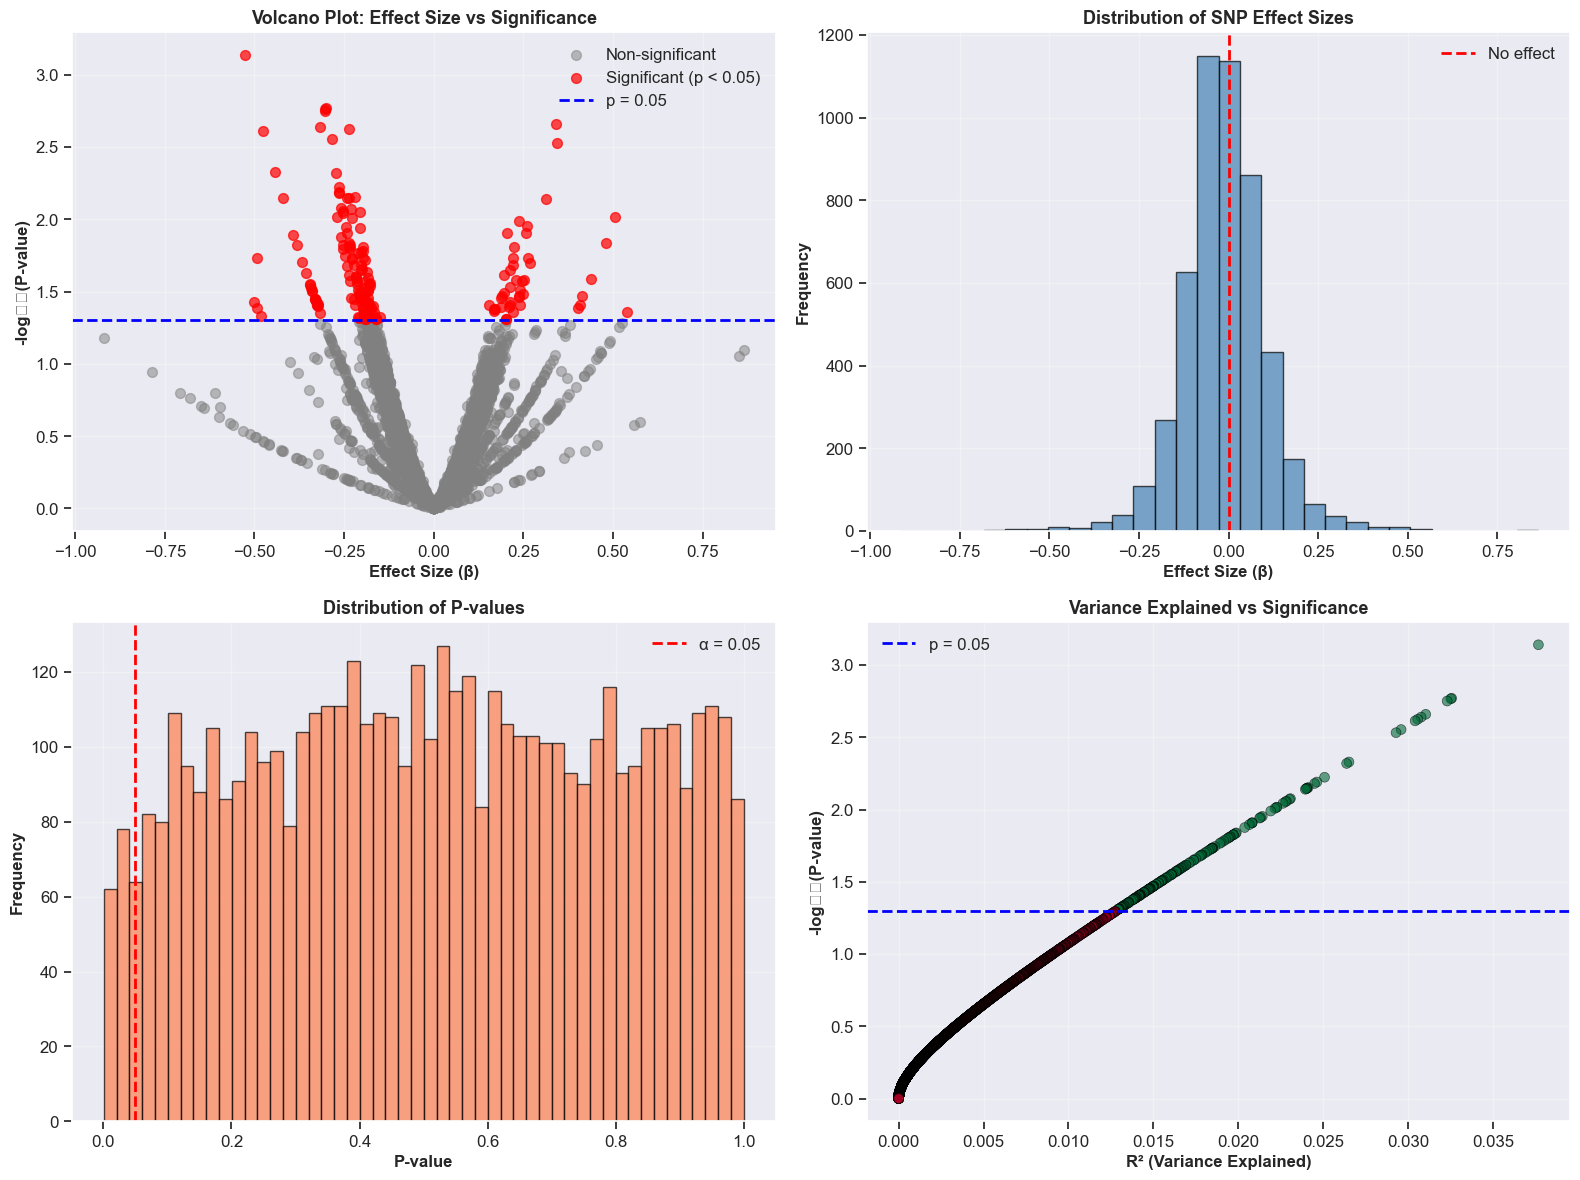


✓ Comprehensive regression analysis complete


In [7]:
# Create a comprehensive visualization of regression results
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Volcano plot: Effect size vs -log10(p-value)
ax1 = axes[0, 0]
significant = eqtl_results['P_value'] < 0.05
ax1.scatter(eqtl_results.loc[~significant, 'Beta'], 
           -np.log10(eqtl_results.loc[~significant, 'P_value']),
           alpha=0.5, s=50, c='gray', label='Non-significant')
ax1.scatter(eqtl_results.loc[significant, 'Beta'], 
           -np.log10(eqtl_results.loc[significant, 'P_value']),
           alpha=0.7, s=50, c='red', label='Significant (p < 0.05)')
ax1.axhline(-np.log10(0.05), color='blue', linestyle='--', linewidth=2, label='p = 0.05')
ax1.set_xlabel('Effect Size (β)', fontsize=12, fontweight='bold')
ax1.set_ylabel('-log₁₀(P-value)', fontsize=12, fontweight='bold')
ax1.set_title('Volcano Plot: Effect Size vs Significance', fontsize=13, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Distribution of effect sizes
ax2 = axes[0, 1]
ax2.hist(eqtl_results['Beta'], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
ax2.axvline(0, color='red', linestyle='--', linewidth=2, label='No effect')
ax2.set_xlabel('Effect Size (β)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax2.set_title('Distribution of SNP Effect Sizes', fontsize=13, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. P-value distribution
ax3 = axes[1, 0]
ax3.hist(eqtl_results['P_value'], bins=50, edgecolor='black', alpha=0.7, color='coral')
ax3.axvline(0.05, color='red', linestyle='--', linewidth=2, label='α = 0.05')
ax3.set_xlabel('P-value', fontsize=12, fontweight='bold')
ax3.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax3.set_title('Distribution of P-values', fontsize=13, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. R-squared vs p-value
ax4 = axes[1, 1]
scatter = ax4.scatter(eqtl_results['R_squared'], 
                     -np.log10(eqtl_results['P_value']),
                     c=eqtl_results['Significant'], 
                     cmap='RdYlGn', alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
ax4.axhline(-np.log10(0.05), color='blue', linestyle='--', linewidth=2, label='p = 0.05')
ax4.set_xlabel('R² (Variance Explained)', fontsize=12, fontweight='bold')
ax4.set_ylabel('-log₁₀(P-value)', fontsize=12, fontweight='bold')
ax4.set_title('Variance Explained vs Significance', fontsize=13, fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n\u2713 Comprehensive regression analysis complete")

---
## Section 2: Handling Confounding Variation

In real-world eQTL studies, gene expression is influenced by many factors beyond genetic variation:

- **Biological confounders**: Age, sex, disease status, cell type composition
- **Technical confounders**: Batch effects, RNA quality, sequencing depth
- **Environmental factors**: Temperature, time of day, stress

Failing to account for these factors can lead to:
- **Spurious associations** (false positives)
- **Masked true associations** (false negatives)
- **Biased effect size estimates**

### Approach: Multiple Linear Regression

We extend our model to include covariates:

$$
\text{Expression}_i = \beta_0 + \beta_1 \times \text{Genotype}_i + \sum_{j=1}^{p} \gamma_j \times \text{Covariate}_{ij} + \epsilon_i
$$

### Covariate Selection Strategy for eQTL Analysis

Our ASD covariates file contains clinical variables. Best practice dictates:

- **Include as covariates**: Age, Sex, ASD diagnosis — known biological confounders of gene expression
- **Do NOT include**: ADOS_Score, Social_Impairment, Repetitive_Behavior — these are downstream phenotypic measures that could be *mediators* between genotype and expression; conditioning on mediators can induce collider bias
- **Hidden confounders**: In Section 3 we will use PCA on the expression matrix itself to capture unmeasured technical variation (analogous to PEER factors or surrogate variables)

### 2.1 Loading and Exploring Clinical Covariates

COVARIATE DATA
Dimensions: 300 individuals × 8 covariates

Columns: ['sample', 'ASD', 'Age', 'Sex', 'IQ', 'ADOS_Score', 'Social_Impairment', 'Repetitive_Behavior', 'ASD_Subgroup']

First 5 rows:
     sample  ASD   Age  Sex   IQ  ADOS_Score  Social_Impairment  \
0  sample_1    1   9.2    0   96        11.0               7.15   
1  sample_2    0  11.4    1  134         0.0               0.65   
2  sample_3    1   7.0    0   95        17.7               7.62   
3  sample_4    0  13.0    0  134         0.0               1.05   
4  sample_5    0  11.2    1   91         0.0               0.17   

   Repetitive_Behavior  ASD_Subgroup  
0                 7.90             3  
1                 0.28             0  
2                 5.71             2  
3                 0.25             0  
4                 0.83             0  

COVARIATE SUMMARY STATISTICS
            ASD       Age       Sex        IQ  ADOS_Score  Social_Impairment  \
count  300.0000  300.0000  300.0000  300.0000    300.0000 

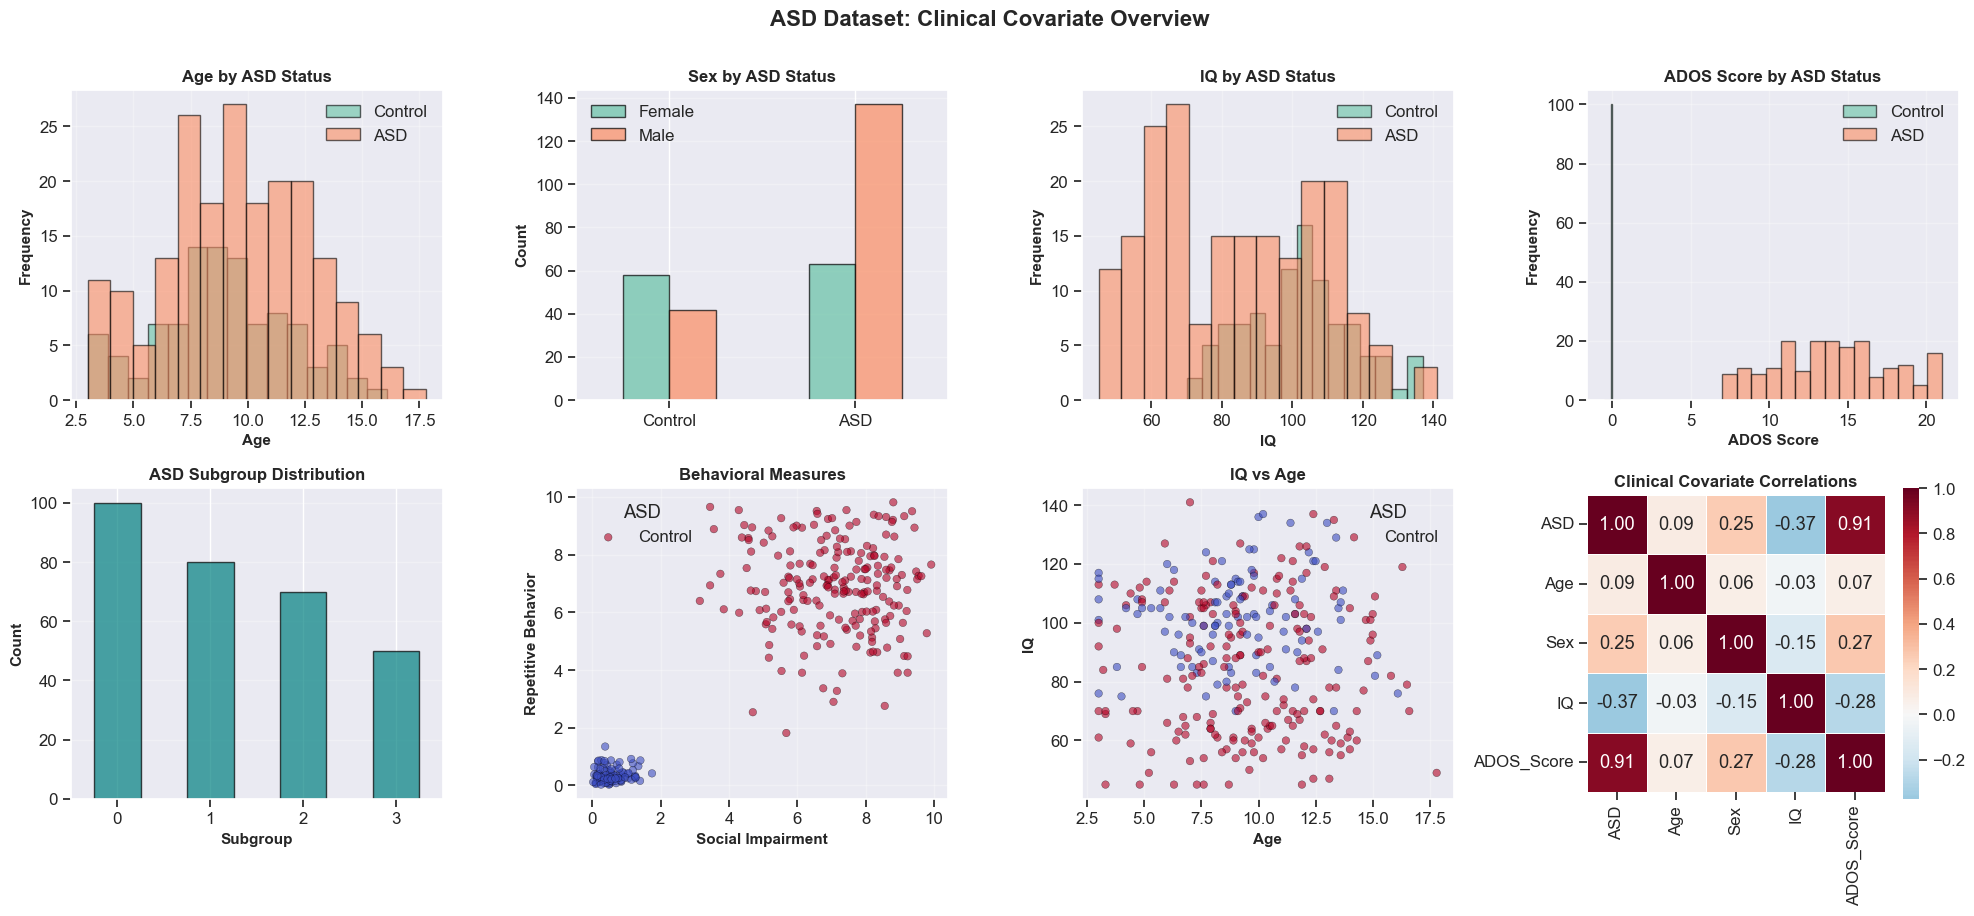


✓ 8 clinical covariates loaded
✓ For eQTL models we will use: Age, Sex, ASD diagnosis (biological confounders)
  Excluded: ADOS_Score, Social_Impairment, Repetitive_Behavior (potential mediators)


In [8]:
# Load covariate data from the ASD dataset
covariates = pd.read_csv('../data/ASD_dataset/ASD_covariates.csv')

print("=" * 70)
print("COVARIATE DATA")
print("=" * 70)
print(f"Dimensions: {covariates.shape[0]} individuals × {covariates.shape[1]-1} covariates")
print(f"\nColumns: {list(covariates.columns)}")
print(f"\nFirst 5 rows:")
print(covariates.head())

# Clinical covariates available
clinical_cols = [c for c in covariates.columns if c != 'sample']

print(f"\n{'='*70}")
print("COVARIATE SUMMARY STATISTICS")
print(f"{'='*70}")
print(covariates[clinical_cols].describe())

print(f"\n{'='*70}")
print("CLINICAL COVARIATE DETAILS")
print(f"{'='*70}")
print(f"  ASD diagnosis: {covariates['ASD'].value_counts().to_dict()} (0=control, 1=case)")
print(f"  Sex: {covariates['Sex'].value_counts().to_dict()} (0=female, 1=male)")
print(f"  Age range: {covariates['Age'].min():.1f} – {covariates['Age'].max():.1f}")
print(f"  IQ range: {covariates['IQ'].min()} – {covariates['IQ'].max()}")
print(f"  ASD Subgroups: {sorted(covariates['ASD_Subgroup'].unique())}")

# Visualize clinical covariates
fig, axes = plt.subplots(2, 4, figsize=(20, 9))

# Age distribution by ASD status
ax = axes[0, 0]
for label, group in covariates.groupby('ASD'):
    ax.hist(group['Age'], bins=15, alpha=0.6, label=f"{'ASD' if label else 'Control'}", edgecolor='black')
ax.set_xlabel('Age', fontsize=11, fontweight='bold')
ax.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax.set_title('Age by ASD Status', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Sex distribution
ax = axes[0, 1]
sex_counts = covariates.groupby(['ASD', 'Sex']).size().unstack(fill_value=0)
sex_counts.index = ['Control', 'ASD']
sex_counts.columns = ['Female', 'Male']
sex_counts.plot(kind='bar', ax=ax, edgecolor='black', alpha=0.7)
ax.set_title('Sex by ASD Status', fontsize=12, fontweight='bold')
ax.set_ylabel('Count', fontsize=11, fontweight='bold')
ax.tick_params(axis='x', rotation=0)
ax.grid(True, alpha=0.3, axis='y')

# IQ distribution
ax = axes[0, 2]
for label, group in covariates.groupby('ASD'):
    ax.hist(group['IQ'], bins=15, alpha=0.6, label=f"{'ASD' if label else 'Control'}", edgecolor='black')
ax.set_xlabel('IQ', fontsize=11, fontweight='bold')
ax.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax.set_title('IQ by ASD Status', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# ADOS Score
ax = axes[0, 3]
for label, group in covariates.groupby('ASD'):
    ax.hist(group['ADOS_Score'], bins=15, alpha=0.6, label=f"{'ASD' if label else 'Control'}", edgecolor='black')
ax.set_xlabel('ADOS Score', fontsize=11, fontweight='bold')
ax.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax.set_title('ADOS Score by ASD Status', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# ASD Subgroup
ax = axes[1, 0]
covariates['ASD_Subgroup'].value_counts().sort_index().plot(kind='bar', ax=ax,
    edgecolor='black', alpha=0.7, color='teal')
ax.set_xlabel('Subgroup', fontsize=11, fontweight='bold')
ax.set_ylabel('Count', fontsize=11, fontweight='bold')
ax.set_title('ASD Subgroup Distribution', fontsize=12, fontweight='bold')
ax.tick_params(axis='x', rotation=0)
ax.grid(True, alpha=0.3, axis='y')

# Social Impairment vs Repetitive Behavior
ax = axes[1, 1]
scatter = ax.scatter(covariates['Social_Impairment'], covariates['Repetitive_Behavior'],
                     c=covariates['ASD'], cmap='coolwarm', alpha=0.6, s=30, edgecolors='black', linewidth=0.3)
ax.set_xlabel('Social Impairment', fontsize=11, fontweight='bold')
ax.set_ylabel('Repetitive Behavior', fontsize=11, fontweight='bold')
ax.set_title('Behavioral Measures', fontsize=12, fontweight='bold')
ax.legend(*scatter.legend_elements(), title='ASD', labels=['Control', 'ASD'])
ax.grid(True, alpha=0.3)

# IQ vs Age
ax = axes[1, 2]
scatter = ax.scatter(covariates['Age'], covariates['IQ'],
                     c=covariates['ASD'], cmap='coolwarm', alpha=0.6, s=30, edgecolors='black', linewidth=0.3)
ax.set_xlabel('Age', fontsize=11, fontweight='bold')
ax.set_ylabel('IQ', fontsize=11, fontweight='bold')
ax.set_title('IQ vs Age', fontsize=12, fontweight='bold')
ax.legend(*scatter.legend_elements(), title='ASD', labels=['Control', 'ASD'])
ax.grid(True, alpha=0.3)

# Correlation between clinical covariates
ax = axes[1, 3]
clinical_corr = covariates[['ASD', 'Age', 'Sex', 'IQ', 'ADOS_Score']].corr()
sns.heatmap(clinical_corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax,
            square=True, linewidths=0.5)
ax.set_title('Clinical Covariate Correlations', fontsize=12, fontweight='bold')

plt.suptitle('ASD Dataset: Clinical Covariate Overview', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print(f"\n✓ {len(clinical_cols)} clinical covariates loaded")
print(f"✓ For eQTL models we will use: Age, Sex, ASD diagnosis (biological confounders)")
print(f"  Excluded: ADOS_Score, Social_Impairment, Repetitive_Behavior (potential mediators)")

### 2.2 Regression With and Without Clinical Covariates

We will compare two models:

1. **Simple model**: Expression ~ Genotype
2. **Clinical model**: Expression ~ Genotype + Age + Sex + ASD

This comparison reveals:
- How clinical covariates affect effect size estimates
- Changes in statistical significance
- Improvement in model fit (R²)

We include **Age**, **Sex**, and **ASD diagnosis** as they are established biological confounders of gene expression that are *not* on the causal path from genotype to expression.

COMPARING MODELS: WITH AND WITHOUT CLINICAL COVARIATES

Clinical covariates used: Age, Sex, ASD diagnosis
  - Age: continuous, mean=9.4
  - Sex: binary (0=F, 1=M), 59.7% male
  - ASD: binary (0=control, 1=case), 66.7% cases



Summary:
  Simple model - Significant associations: 173
  With clinical covariates - Significant associations: 156

Top 10 associations with clinical covariates:

   SNP    Gene    Beta     SE  CI_Lower  CI_Upper  P_value  R_squared  Significant
 snp_4 CACNA1B -0.5361 0.1551   -0.8415   -0.2308   0.0006     0.0536         True
snp_30   NCAM1  0.3537 0.1111    0.1350    0.5724   0.0016     0.0373         True
 snp_4 NEUROD1 -0.4906 0.1564   -0.7983   -0.1829   0.0019     0.0425         True
snp_48   KCNQ2 -0.3009 0.0960   -0.4899   -0.1119   0.0019     0.0438         True
snp_48    MBD5 -0.2966 0.0963   -0.4861   -0.1071   0.0023     0.0391         True
snp_28   CREB1 -0.2867 0.0953   -0.4742   -0.0991   0.0029     0.0507         True
snp_48   DSCAM -0.2820 0.0945   -0.4680   -0.0960   0.0031     0.0311         True
snp_13  GABRG2 -0.3090 0.1045   -0.5147   -0.1033   0.0034     0.0423         True
snp_40    SYN1 -0.2278 0.0784   -0.3820   -0.0736   0.0039     0.0455         True
snp_44

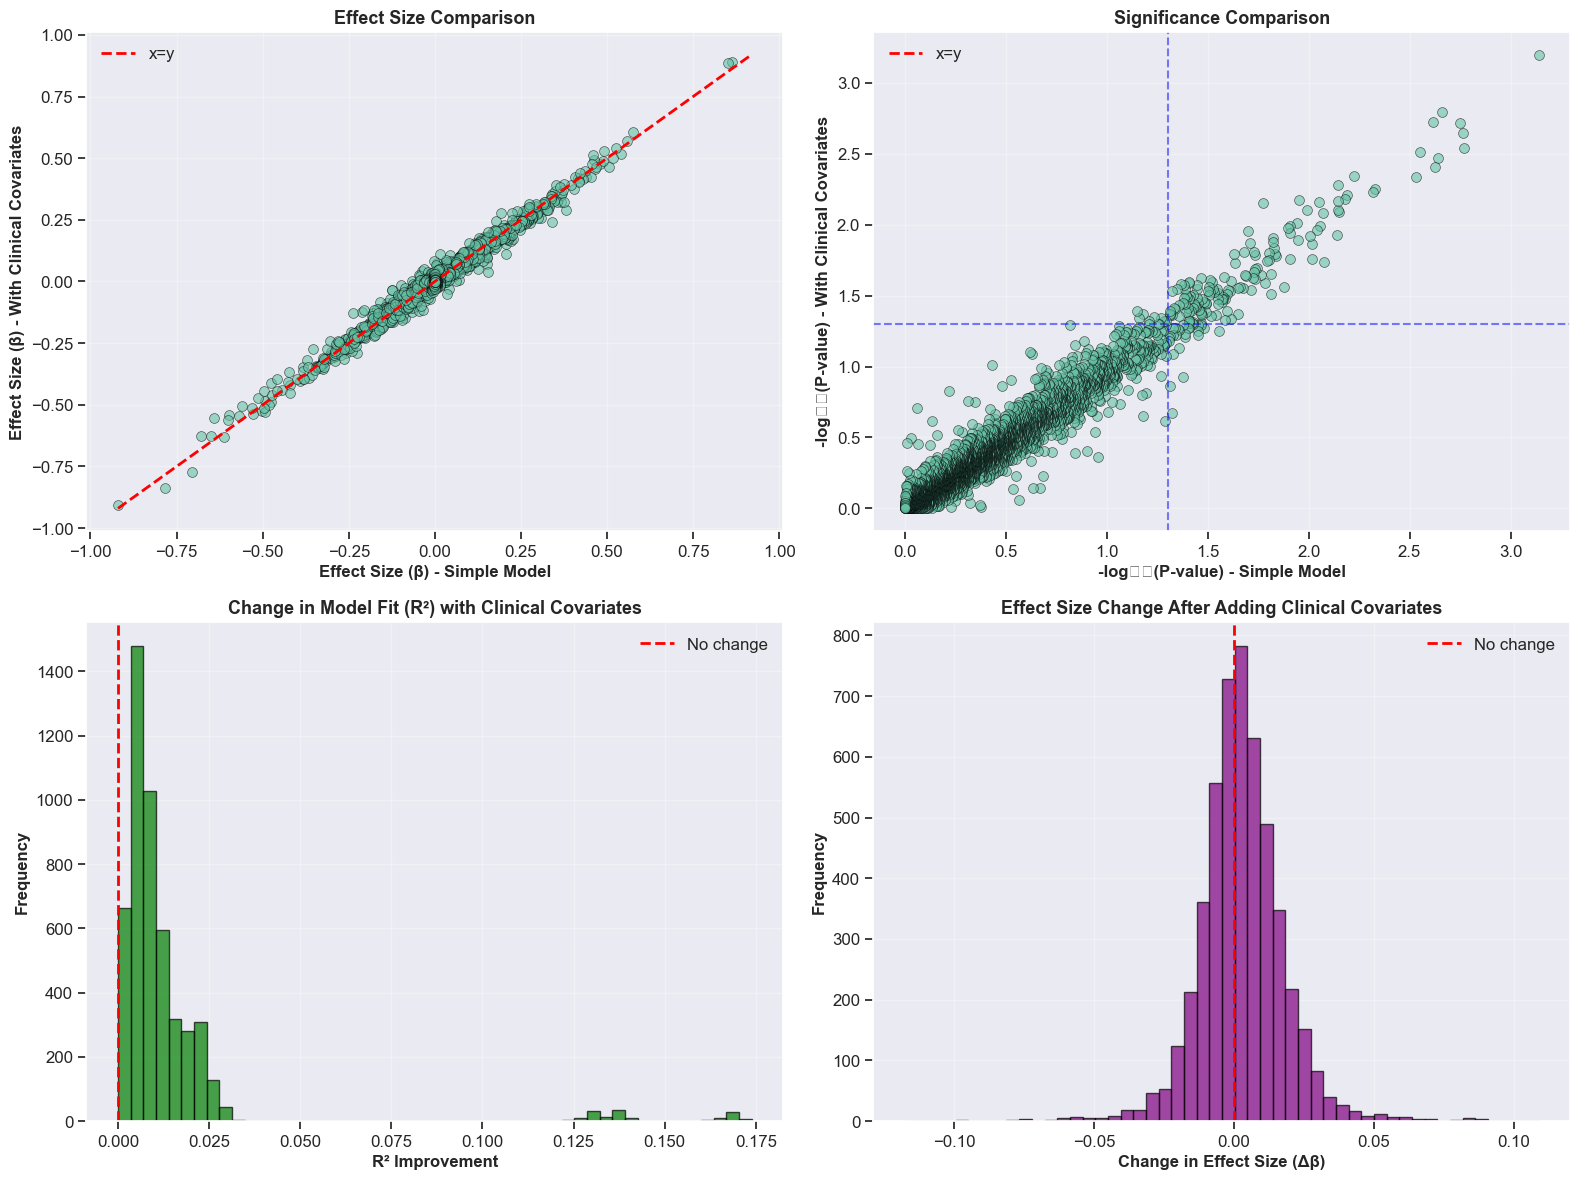


IMPACT OF CLINICAL COVARIATES
Mean R² improvement: 0.0137
Mean absolute beta change: 0.0112
Associations gaining significance: 8
Associations losing significance: 25

✓ Clinical covariate analysis complete


In [9]:
def perform_eqtl_regression_with_covariates(genotype, expression, covariates_data, snp_name, gene_name):
    """
    Perform linear regression with covariates for a single SNP-gene pair.
    
    Parameters:
    -----------
    genotype : array-like
        Genotype values (0, 1, 2) for all individuals
    expression : array-like
        Expression values for all individuals
    covariates_data : DataFrame or ndarray
        Covariate matrix (excluding sample ID)
    snp_name : str
        Name of the SNP
    gene_name : str
        Name of the gene
    
    Returns:
    --------
    dict : Dictionary containing regression results
    """
    # Prepare design matrix: genotype + covariates
    if hasattr(covariates_data, 'values'):
        cov_vals = covariates_data.values
    else:
        cov_vals = covariates_data
    X = np.column_stack([genotype, cov_vals])
    X = sm.add_constant(X)
    y = expression
    
    # Ordinary Least Squares is the standard method used to estimate parameters in linear regression models
    model = sm.OLS(y, X).fit()  # computes coefficients by minimizing squared residual error
    
    # Extract results (index 1 corresponds to genotype after constant)
    beta = model.params[1]
    se = model.bse[1]
    ci_lower, ci_upper = model.conf_int()[1]
    pval = model.pvalues[1]
    rsquared = model.rsquared
    
    return {
        'SNP': snp_name,
        'Gene': gene_name,
        'Beta': beta,
        'SE': se,
        'CI_Lower': ci_lower,
        'CI_Upper': ci_upper,
        'P_value': pval,
        'R_squared': rsquared
    }

# Select clinical covariates: Age, Sex, ASD diagnosis
# These are established biological confounders of gene expression
clinical_covariates = covariates[['Age', 'Sex', 'ASD']].copy()

print("=" * 70)
print(f"COMPARING MODELS: WITH AND WITHOUT CLINICAL COVARIATES")
print("=" * 70)
print(f"\nClinical covariates used: Age, Sex, ASD diagnosis")
print(f"  - Age: continuous, mean={clinical_covariates['Age'].mean():.1f}")
print(f"  - Sex: binary (0=F, 1=M), {clinical_covariates['Sex'].mean():.1%} male")
print(f"  - ASD: binary (0=control, 1=case), {clinical_covariates['ASD'].mean():.1%} cases")

# Run analysis for all SNP-gene pairs with clinical covariates
all_results_with_cov = []
for snp in geno.columns[1:]:
    for gene in expr.columns[1:]:
        result = perform_eqtl_regression_with_covariates(
            genotype=geno[snp].values,
            expression=expr[gene].values,
            covariates_data=clinical_covariates,
            snp_name=snp,
            gene_name=gene
        )
        all_results_with_cov.append(result)

# Convert to DataFrame
eqtl_results_with_cov = pd.DataFrame(all_results_with_cov)
eqtl_results_with_cov['Significant'] = eqtl_results_with_cov['P_value'] < 0.05
eqtl_results_with_cov = eqtl_results_with_cov.sort_values('P_value')

# Merge results for comparison
comparison = eqtl_results[['SNP', 'Gene', 'Beta', 'P_value', 'R_squared']].merge(
    eqtl_results_with_cov[['SNP', 'Gene', 'Beta', 'P_value', 'R_squared']],
    on=['SNP', 'Gene'],
    suffixes=('_simple', '_with_cov')
)

# Calculate differences
comparison['Beta_change'] = comparison['Beta_with_cov'] - comparison['Beta_simple']
comparison['Pval_change'] = comparison['P_value_with_cov'] - comparison['P_value_simple']
comparison['Rsq_improvement'] = comparison['R_squared_with_cov'] - comparison['R_squared_simple']

print(f"\nSummary:")
print(f"  Simple model - Significant associations: {eqtl_results['Significant'].sum()}")
print(f"  With clinical covariates - Significant associations: {eqtl_results_with_cov['Significant'].sum()}")
print(f"\nTop 10 associations with clinical covariates:\n")
print(eqtl_results_with_cov.head(10).to_string(index=False))

# Visualize comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Beta comparison
ax1 = axes[0, 0]
ax1.scatter(comparison['Beta_simple'], comparison['Beta_with_cov'], 
           alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
lim = max(abs(comparison['Beta_simple'].min()), abs(comparison['Beta_simple'].max()),
          abs(comparison['Beta_with_cov'].min()), abs(comparison['Beta_with_cov'].max()))
ax1.plot([-lim, lim], [-lim, lim], 'r--', linewidth=2, label='x=y')
ax1.set_xlabel('Effect Size (β) - Simple Model', fontsize=12, fontweight='bold')
ax1.set_ylabel('Effect Size (β) - With Clinical Covariates', fontsize=12, fontweight='bold')
ax1.set_title('Effect Size Comparison', fontsize=13, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. P-value comparison
ax2 = axes[0, 1]
ax2.scatter(-np.log10(comparison['P_value_simple']), 
           -np.log10(comparison['P_value_with_cov']),
           alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
lim = max(-np.log10(comparison['P_value_simple']).max(),
          -np.log10(comparison['P_value_with_cov']).max())
ax2.plot([0, lim], [0, lim], 'r--', linewidth=2, label='x=y')
ax2.axhline(-np.log10(0.05), color='blue', linestyle='--', alpha=0.5)
ax2.axvline(-np.log10(0.05), color='blue', linestyle='--', alpha=0.5)
ax2.set_xlabel('-log₁₀(P-value) - Simple Model', fontsize=12, fontweight='bold')
ax2.set_ylabel('-log₁₀(P-value) - With Clinical Covariates', fontsize=12, fontweight='bold')
ax2.set_title('Significance Comparison', fontsize=13, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. R-squared improvement
ax3 = axes[1, 0]
ax3.hist(comparison['Rsq_improvement'], bins=50, edgecolor='black', alpha=0.7, color='green')
ax3.axvline(0, color='red', linestyle='--', linewidth=2, label='No change')
ax3.set_xlabel('R² Improvement', fontsize=12, fontweight='bold')
ax3.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax3.set_title('Change in Model Fit (R²) with Clinical Covariates', fontsize=13, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Effect size change distribution
ax4 = axes[1, 1]
ax4.hist(comparison['Beta_change'], bins=50, edgecolor='black', alpha=0.7, color='purple')
ax4.axvline(0, color='red', linestyle='--', linewidth=2, label='No change')
ax4.set_xlabel('Change in Effect Size (Δβ)', fontsize=12, fontweight='bold')
ax4.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax4.set_title('Effect Size Change After Adding Clinical Covariates', fontsize=13, fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n{'='*70}")
print("IMPACT OF CLINICAL COVARIATES")
print(f"{'='*70}")
print(f"Mean R² improvement: {comparison['Rsq_improvement'].mean():.4f}")
print(f"Mean absolute beta change: {comparison['Beta_change'].abs().mean():.4f}")
print(f"Associations gaining significance: {((comparison['P_value_simple'] >= 0.05) & (comparison['P_value_with_cov'] < 0.05)).sum()}")
print(f"Associations losing significance: {((comparison['P_value_simple'] < 0.05) & (comparison['P_value_with_cov'] >= 0.05)).sum()}")
print("\n✓ Clinical covariate analysis complete")

---
## Section 3: Expression PCA as Proxy for Hidden Confounders

In production eQTL pipelines (GTEx, eQTLGen), hidden technical variation is captured using **PEER factors** or **surrogate variables (SVA)** — latent factors estimated from the expression matrix itself. These methods identify shared axes of variation across many genes that likely reflect unmeasured confounders (batch effects, RNA quality, cell composition) rather than genetic signal.

**PCA on the expression matrix** is a practical, widely-accepted alternative that captures the same hidden structure:
- The top PCs of the expression matrix absorb dominant non-genetic variation
- Adding these as covariates improves eQTL detection power
- GTEx has shown PCA-based approaches perform comparably to PEER

### Strategy

We compute PCs directly from the **expression matrix** and combine the top PCs with our clinical covariates (Age, Sex, ASD) to build the final model:

$$
\text{Expression}_i = \beta_0 + \beta_1 \times \text{Genotype}_i + \gamma_1 \text{Age}_i + \gamma_2 \text{Sex}_i + \gamma_3 \text{ASD}_i + \sum_{k=1}^{K} \delta_k \text{exprPC}_{ki} + \epsilon_i
$$

**Note**: The number of PCs matters — too few leaves confounding in, too many absorbs real genetic signal. A common heuristic is 10–60 PCs depending on sample size.

### 3.1 Computing Principal Components from the Expression Matrix

EXPRESSION PCA: CAPTURING HIDDEN CONFOUNDERS

Expression matrix: 300 samples × 100 genes

PCA Results:
  - Number of components: 100
  - Variance explained by PC1: 0.5298 (53.0%)
  - Variance explained by top 10 PCs: 0.6440 (64.4%)

First 5 rows of expression PCs:
   exprPC1  exprPC2  exprPC3  exprPC4  exprPC5  exprPC6  exprPC7  exprPC8  \
0  -0.1418   0.7955   0.0124   1.0022  -0.3028  -0.2835   2.7641   0.3452   
1   8.2396   2.5708  -0.5997  -0.5283  -0.3195   0.8599   0.9340   1.2358   
2   4.5704   0.5582   0.6223  -1.4597  -1.5944  -0.2979   0.1480   0.2411   
3 -12.0518  -1.9461   1.1405  -0.1992  -0.4483   0.9722   0.4537  -0.4416   
4  -8.7168   0.6682  -3.2252   0.0326   1.2151   0.3522   2.3441   0.5886   

   exprPC9  exprPC10  
0  -1.1549    1.5274  
1   0.0903    0.2050  
2   0.6099   -0.7189  
3  -0.0006   -0.1260  
4   0.6455   -0.2719  


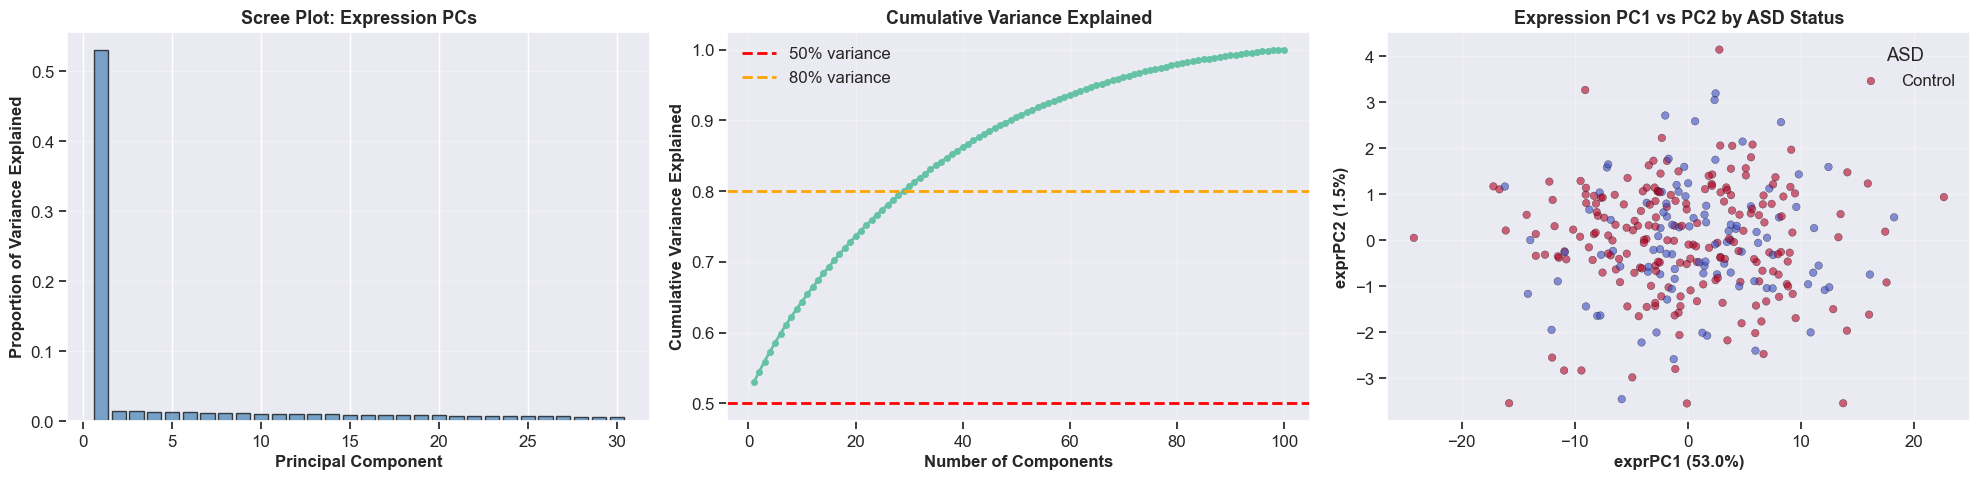


PC SELECTION
Selected 10 expression PCs (heuristic for n=300 samples)
Variance explained by top 10 PCs: 0.6440 (64.4%)

Variance per PC (top 10):
  exprPC1: 0.5298 (52.98%)
  exprPC2: 0.0151 (1.51%)
  exprPC3: 0.0143 (1.43%)
  exprPC4: 0.0137 (1.37%)
  exprPC5: 0.0131 (1.31%)
  exprPC6: 0.0128 (1.28%)
  exprPC7: 0.0122 (1.22%)
  exprPC8: 0.0113 (1.13%)
  exprPC9: 0.0111 (1.11%)
  exprPC10: 0.0106 (1.06%)

✓ Expression PCA complete


In [10]:
print("=" * 70)
print("EXPRESSION PCA: CAPTURING HIDDEN CONFOUNDERS")
print("=" * 70)

# Extract expression matrix (exclude sample column)
expr_matrix = expr.iloc[:, 1:].values
print(f"\nExpression matrix: {expr_matrix.shape[0]} samples × {expr_matrix.shape[1]} genes")

# Standardize expression (mean=0, std=1) before PCA
# This ensures all genes contribute equally regardless of expression level
scaler = StandardScaler()
expr_scaled = scaler.fit_transform(expr_matrix)

# Compute PCA
pca = PCA()
pcs = pca.fit_transform(expr_scaled)

# Convert to DataFrame
pcs_df = pd.DataFrame(
    pcs,
    columns=[f'exprPC{i+1}' for i in range(pcs.shape[1])]
)

print(f"\nPCA Results:")
print(f"  - Number of components: {pcs.shape[1]}")
print(f"  - Variance explained by PC1: {pca.explained_variance_ratio_[0]:.4f} ({pca.explained_variance_ratio_[0]*100:.1f}%)")
print(f"  - Variance explained by top 10 PCs: {pca.explained_variance_ratio_[:10].sum():.4f} ({pca.explained_variance_ratio_[:10].sum()*100:.1f}%)")
print(f"\nFirst 5 rows of expression PCs:")
print(pcs_df.iloc[:, :10].head())

# Visualize explained variance
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1. Scree plot
ax1 = axes[0]
n_show = min(30, len(pca.explained_variance_ratio_))
ax1.bar(range(1, n_show+1), pca.explained_variance_ratio_[:n_show],
        edgecolor='black', alpha=0.7, color='steelblue')
ax1.set_xlabel('Principal Component', fontsize=12, fontweight='bold')
ax1.set_ylabel('Proportion of Variance Explained', fontsize=12, fontweight='bold')
ax1.set_title('Scree Plot: Expression PCs', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')

# 2. Cumulative variance explained
ax2 = axes[1]
cumvar = np.cumsum(pca.explained_variance_ratio_)
ax2.plot(range(1, len(cumvar)+1), cumvar, 'o-', linewidth=2, markersize=4)
ax2.axhline(0.5, color='red', linestyle='--', linewidth=2, label='50% variance')
ax2.axhline(0.8, color='orange', linestyle='--', linewidth=2, label='80% variance')
ax2.set_xlabel('Number of Components', fontsize=12, fontweight='bold')
ax2.set_ylabel('Cumulative Variance Explained', fontsize=12, fontweight='bold')
ax2.set_title('Cumulative Variance Explained', fontsize=13, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. PC1 vs PC2 colored by ASD status
ax3 = axes[2]
scatter = ax3.scatter(pcs_df['exprPC1'], pcs_df['exprPC2'],
                      c=covariates['ASD'], cmap='coolwarm', alpha=0.6, s=30,
                      edgecolors='black', linewidth=0.3)
ax3.set_xlabel(f'exprPC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12, fontweight='bold')
ax3.set_ylabel(f'exprPC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12, fontweight='bold')
ax3.set_title('Expression PC1 vs PC2 by ASD Status', fontsize=13, fontweight='bold')
ax3.legend(*scatter.legend_elements(), title='ASD', labels=['Control', 'ASD'])
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Select number of PCs: for n=300, use 10 PCs (conservative for small sample)
n_pcs = 10
print(f"\n{'='*70}")
print(f"PC SELECTION")
print(f"{'='*70}")
print(f"Selected {n_pcs} expression PCs (heuristic for n={expr_matrix.shape[0]} samples)")
print(f"Variance explained by top {n_pcs} PCs: {cumvar[n_pcs-1]:.4f} ({cumvar[n_pcs-1]*100:.1f}%)")
print(f"\nVariance per PC (top {n_pcs}):")
for i in range(n_pcs):
    print(f"  exprPC{i+1}: {pca.explained_variance_ratio_[i]:.4f} ({pca.explained_variance_ratio_[i]*100:.2f}%)")

print("\n✓ Expression PCA complete")

### 3.2 eQTL Analysis with Clinical Covariates + Expression PCs

We now build our **full model** combining:
- Clinical covariates (Age, Sex, ASD) — known biological confounders
- Top expression PCs — capturing hidden technical/batch variation (analogous to PEER factors)

This is the standard approach in large-scale eQTL studies (GTEx, eQTLGen).

eQTL ANALYSIS: CLINICAL COVARIATES + 10 EXPRESSION PCs

Full covariate set (13 variables):
  Clinical: Age, Sex, ASD
  Expression PCs: exprPC1–exprPC10 (capturing 64.4% of expression variance)



Significant associations with full model: 255

Top 10 associations (clinical + expression PCs):

   SNP    Gene    Beta     SE  CI_Lower  CI_Upper    P_value  R_squared  Significant
snp_30   NCAM1  0.2797 0.0699    0.1421    0.4173 8.0479e-05     0.6505         True
 snp_3   SCN3A -0.4580 0.1302   -0.7142   -0.2017 5.0572e-04     0.7864         True
snp_17  DYRK1A -0.2466 0.0705   -0.3854   -0.1078 5.4502e-04     0.5338         True
snp_39   KMT2E  0.2082 0.0616    0.0870    0.3294 8.2381e-04     0.7498         True
snp_13  GABRG2 -0.2134 0.0643   -0.3400   -0.0867 1.0308e-03     0.6576         True
snp_29    GRM1  0.2065 0.0628    0.0829    0.3301 1.1375e-03     0.5531         True
snp_21   KMT2E -0.1941 0.0596   -0.3114   -0.0767 1.2691e-03     0.7491         True
snp_40 KIRREL3  0.2010 0.0626    0.0777    0.3243 1.4890e-03     0.4745         True
snp_50  CAMK2B -0.1135 0.0355   -0.1834   -0.0435 1.5638e-03     0.8350         True
 snp_3   DEAF1 -0.4032 0.1268   -0.6528   -0.1537 1.

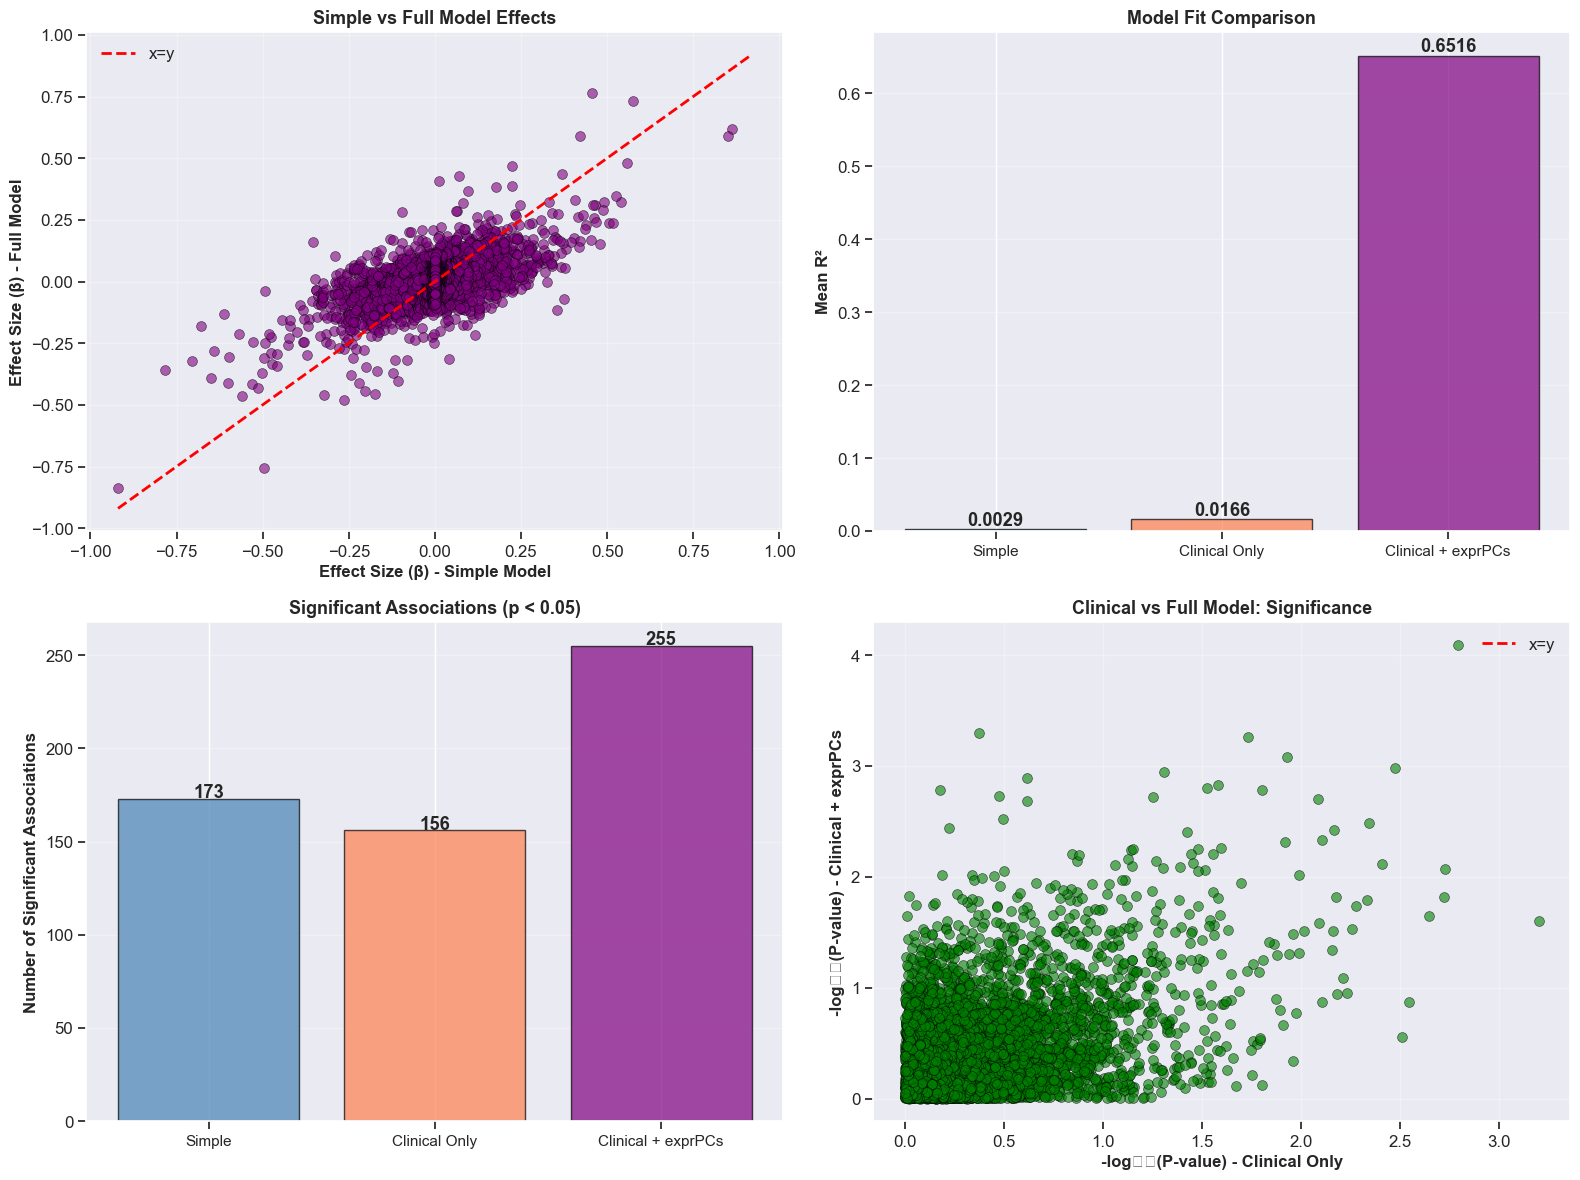


MODEL COMPARISON SUMMARY

Model                     Sig. Assoc.     Mean R²         Mean |β|       
----------------------------------------------------------------------
Simple                    173             0.0029          0.0882         
Clinical Only             156             0.0166          0.0873         
Clinical + exprPCs        255             0.6516          0.0568         

✓ Full model analysis complete


In [11]:
# Build the full covariate matrix: clinical + top expression PCs
pcs_subset = pcs_df.iloc[:, :n_pcs]

# Combine clinical covariates with expression PCs
full_covariates = pd.concat([clinical_covariates.reset_index(drop=True),
                              pcs_subset.reset_index(drop=True)], axis=1)

print("=" * 70)
print(f"eQTL ANALYSIS: CLINICAL COVARIATES + {n_pcs} EXPRESSION PCs")
print("=" * 70)
print(f"\nFull covariate set ({full_covariates.shape[1]} variables):")
print(f"  Clinical: Age, Sex, ASD")
print(f"  Expression PCs: exprPC1–exprPC{n_pcs} (capturing {cumvar[n_pcs-1]*100:.1f}% of expression variance)")

# Run analysis with full covariates
all_results_with_pcs = []
for snp in geno.columns[1:]:
    for gene in expr.columns[1:]:
        result = perform_eqtl_regression_with_covariates(
            genotype=geno[snp].values,
            expression=expr[gene].values,
            covariates_data=full_covariates,
            snp_name=snp,
            gene_name=gene
        )
        all_results_with_pcs.append(result)

# Convert to DataFrame
eqtl_results_with_pcs = pd.DataFrame(all_results_with_pcs)
eqtl_results_with_pcs['Significant'] = eqtl_results_with_pcs['P_value'] < 0.05
eqtl_results_with_pcs = eqtl_results_with_pcs.sort_values('P_value')

print(f"\nSignificant associations with full model: {eqtl_results_with_pcs['Significant'].sum()}")
print(f"\nTop 10 associations (clinical + expression PCs):\n")
print(eqtl_results_with_pcs.head(10).to_string(index=False))

# Compare three models: simple, clinical only, clinical + expression PCs
comparison_all = eqtl_results[['SNP', 'Gene', 'Beta', 'P_value', 'R_squared']].merge(
    eqtl_results_with_cov[['SNP', 'Gene', 'Beta', 'P_value', 'R_squared']],
    on=['SNP', 'Gene'],
    suffixes=('_simple', '_cov')
).merge(
    eqtl_results_with_pcs[['SNP', 'Gene', 'Beta', 'P_value', 'R_squared']],
    on=['SNP', 'Gene']
)
comparison_all.rename(columns={'Beta': 'Beta_full', 'P_value': 'P_value_full', 'R_squared': 'R_squared_full'}, inplace=True)

# Visualize three-way comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Beta comparison: Simple vs Full model
ax1 = axes[0, 0]
ax1.scatter(comparison_all['Beta_simple'], comparison_all['Beta_full'], 
           alpha=0.6, s=50, edgecolors='black', linewidth=0.5, color='purple')
lim = max(abs(comparison_all['Beta_simple']).max(), abs(comparison_all['Beta_full']).max())
ax1.plot([-lim, lim], [-lim, lim], 'r--', linewidth=2, label='x=y')
ax1.set_xlabel('Effect Size (β) - Simple Model', fontsize=12, fontweight='bold')
ax1.set_ylabel('Effect Size (β) - Full Model', fontsize=12, fontweight='bold')
ax1.set_title('Simple vs Full Model Effects', fontsize=13, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. R-squared comparison across three models
ax2 = axes[0, 1]
x_pos = np.arange(3)
rsq_means = [
    comparison_all['R_squared_simple'].mean(),
    comparison_all['R_squared_cov'].mean(),
    comparison_all['R_squared_full'].mean()
]
ax2.bar(x_pos, rsq_means, edgecolor='black', alpha=0.7, 
        color=['steelblue', 'coral', 'purple'])
ax2.set_xticks(x_pos)
ax2.set_xticklabels(['Simple', 'Clinical Only', 'Clinical + exprPCs'], fontsize=11)
ax2.set_ylabel('Mean R²', fontsize=12, fontweight='bold')
ax2.set_title('Model Fit Comparison', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')
for i, v in enumerate(rsq_means):
    ax2.text(i, v + 0.005, f'{v:.4f}', ha='center', fontweight='bold')

# 3. Significant associations across three models
ax3 = axes[1, 0]
sig_counts = [
    eqtl_results['Significant'].sum(),
    eqtl_results_with_cov['Significant'].sum(),
    eqtl_results_with_pcs['Significant'].sum()
]
ax3.bar(x_pos, sig_counts, edgecolor='black', alpha=0.7,
        color=['steelblue', 'coral', 'purple'])
ax3.set_xticks(x_pos)
ax3.set_xticklabels(['Simple', 'Clinical Only', 'Clinical + exprPCs'], fontsize=11)
ax3.set_ylabel('Number of Significant Associations', fontsize=12, fontweight='bold')
ax3.set_title('Significant Associations (p < 0.05)', fontsize=13, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')
for i, v in enumerate(sig_counts):
    ax3.text(i, v + 0.5, str(v), ha='center', fontweight='bold')

# 4. P-value comparison: Clinical vs Full
ax4 = axes[1, 1]
ax4.scatter(-np.log10(comparison_all['P_value_cov']), 
           -np.log10(comparison_all['P_value_full']),
           alpha=0.6, s=50, edgecolors='black', linewidth=0.5, color='green')
lim = max(-np.log10(comparison_all['P_value_cov']).max(),
          -np.log10(comparison_all['P_value_full']).max())
ax4.plot([0, lim], [0, lim], 'r--', linewidth=2, label='x=y')
ax4.set_xlabel('-log₁₀(P-value) - Clinical Only', fontsize=12, fontweight='bold')
ax4.set_ylabel('-log₁₀(P-value) - Clinical + exprPCs', fontsize=12, fontweight='bold')
ax4.set_title('Clinical vs Full Model: Significance', fontsize=13, fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n{'='*70}")
print("MODEL COMPARISON SUMMARY")
print(f"{'='*70}")
print(f"\n{'Model':<25} {'Sig. Assoc.':<15} {'Mean R²':<15} {'Mean |β|':<15}")
print("-" * 70)
print(f"{'Simple':<25} {sig_counts[0]:<15} {rsq_means[0]:<15.4f} {comparison_all['Beta_simple'].abs().mean():<15.4f}")
print(f"{'Clinical Only':<25} {sig_counts[1]:<15} {rsq_means[1]:<15.4f} {comparison_all['Beta_cov'].abs().mean():<15.4f}")
print(f"{'Clinical + exprPCs':<25} {sig_counts[2]:<15} {rsq_means[2]:<15.4f} {comparison_all['Beta_full'].abs().mean():<15.4f}")

print("\n✓ Full model analysis complete")

---
## Section 4: Genome-Wide eQTL Analysis

In genome-wide eQTL studies, we test:
- **Thousands to millions of SNPs**
- **Tens of thousands of genes**
- **Billions of SNP-gene pairs**

This scale introduces several challenges:

### 4.1 Multiple Testing Problem

When performing many tests, we expect false positives by chance:
- At α = 0.05, we expect 5% false positives
- With 1,000,000 tests, that's 50,000 false positives!

**Solution**: Adjust p-values for multiple testing:
- **Bonferroni correction**: Divide α by number of tests (conservative)
- **FDR (False Discovery Rate)**: Control proportion of false discoveries (less conservative)

### 4.2 Computational Efficiency

Linear regression for millions of tests requires optimization:
- Matrix operations instead of loops
- Efficient data structures
- Parallel processing

In this section, we'll perform a comprehensive analysis of all SNP-gene pairs and apply multiple testing corrections.

### 4.1 Comprehensive eQTL Mapping with Multiple Testing Correction

In [12]:
print("=" * 70)
print("GENOME-WIDE eQTL ANALYSIS WITH MULTIPLE TESTING CORRECTION")
print("=" * 70)

# Use the best model from previous analysis (with PCs)
results_final = eqtl_results_with_pcs.copy()

# Apply multiple testing corrections
# 1. Bonferroni correction
bonferroni_threshold = 0.05 / len(results_final)
results_final['Bonferroni_significant'] = results_final['P_value'] < bonferroni_threshold

# 2. FDR correction (Benjamini-Hochberg)
_, pvals_fdr, _, _ = multipletests(results_final['P_value'], alpha=0.05, method='fdr_bh')
results_final['P_value_FDR'] = pvals_fdr
results_final['FDR_significant'] = results_final['P_value_FDR'] < 0.05

print(f"\nMultiple Testing Results:")
print(f"  - Total tests performed: {len(results_final):,}")
print(f"  - Bonferroni threshold (α=0.05): {bonferroni_threshold:.2e}")
print(f"  - Nominal significant (p < 0.05): {results_final['Significant'].sum()}")
print(f"  - Bonferroni significant: {results_final['Bonferroni_significant'].sum()}")
print(f"  - FDR significant (q < 0.05): {results_final['FDR_significant'].sum()}")

# Sort by FDR-adjusted p-value
results_final = results_final.sort_values('P_value_FDR')

print(f"\n{'='*70}")
print("TOP 15 SIGNIFICANT eQTLs (FDR < 0.05)")
print(f"{'='*70}\n")
top_eqtls = results_final[results_final['FDR_significant']].head(15)
if len(top_eqtls) > 0:
    print(top_eqtls[['SNP', 'Gene', 'Beta', 'CI_Lower', 'CI_Upper', 'P_value', 'P_value_FDR', 'R_squared']].to_string(index=False))
else:
    print("No associations pass FDR threshold.")
    print("\nTop 10 associations by nominal p-value:")
    print(results_final[['SNP', 'Gene', 'Beta', 'P_value', 'P_value_FDR', 'R_squared']].head(10).to_string(index=False))

GENOME-WIDE eQTL ANALYSIS WITH MULTIPLE TESTING CORRECTION

Multiple Testing Results:
  - Total tests performed: 5,000
  - Bonferroni threshold (α=0.05): 1.00e-05
  - Nominal significant (p < 0.05): 255
  - Bonferroni significant: 0
  - FDR significant (q < 0.05): 0

TOP 15 SIGNIFICANT eQTLs (FDR < 0.05)

No associations pass FDR threshold.

Top 10 associations by nominal p-value:
   SNP    Gene    Beta    P_value  P_value_FDR  R_squared
snp_30   NCAM1  0.2797 8.0479e-05       0.4024     0.6505
snp_35    DRD2 -0.1011 2.0483e-03       0.6828     0.8610
snp_11   CREB5 -0.1281 1.9827e-03       0.6828     0.8035
snp_45     NF1 -0.2172 1.9152e-03       0.6828     0.6263
snp_14 KIRREL3  0.2228 1.6581e-03       0.6828     0.4741
 snp_3   DEAF1 -0.4032 1.6326e-03       0.6828     0.7974
snp_50  CAMK2B -0.1135 1.5638e-03       0.6828     0.8350
 snp_5   EHMT1 -0.3611 1.8774e-03       0.6828     0.6906
snp_21   KMT2E -0.1941 1.2691e-03       0.6828     0.7491
snp_29    GRM1  0.2065 1.1375e-03   

### 4.2 Manhattan Plot: Genome-Wide Visualization

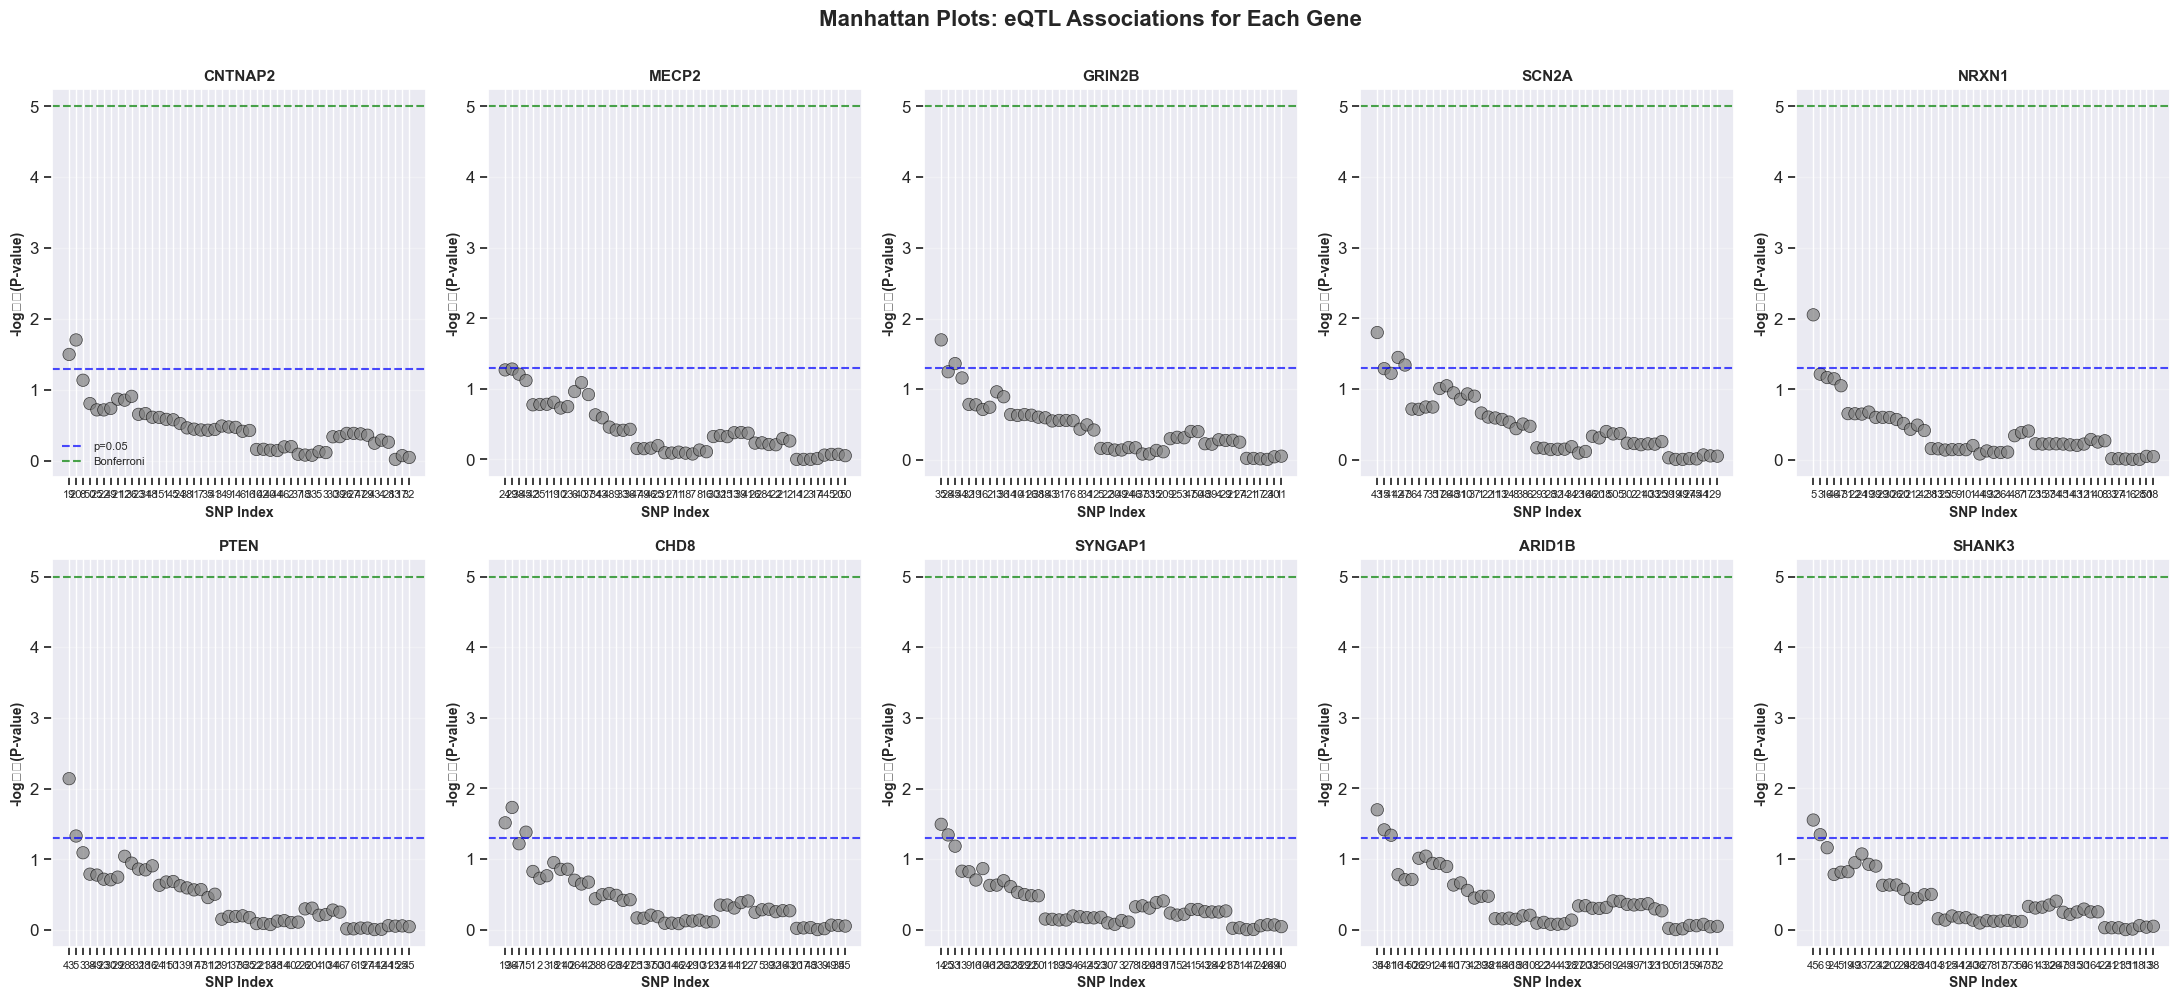


✓ Manhattan plots generated


In [13]:
# Create Manhattan-style plot (one per gene)
fig, axes = plt.subplots(2, 5, figsize=(22, 10))
axes = axes.flatten()

for idx, gene in enumerate(expr.columns[1:][:10]):
    ax = axes[idx]
    gene_results = results_final[results_final['Gene'] == gene].copy()
    
    # Plot -log10(p-values)
    x = range(len(gene_results))
    y = -np.log10(gene_results['P_value'])
    
    # Color by significance
    colors = ['red' if fdr else 'gray' for fdr in gene_results['FDR_significant']]
    
    ax.scatter(x, y, c=colors, s=80, alpha=0.7, edgecolors='black', linewidth=0.5)
    
    # Add significance thresholds
    ax.axhline(-np.log10(0.05), color='blue', linestyle='--', linewidth=1.5, 
              alpha=0.7, label='p=0.05')
    ax.axhline(-np.log10(bonferroni_threshold), color='green', linestyle='--', 
              linewidth=1.5, alpha=0.7, label='Bonferroni')
    
    ax.set_xlabel('SNP Index', fontsize=10, fontweight='bold')
    ax.set_ylabel('-log₁₀(P-value)', fontsize=10, fontweight='bold')
    ax.set_title(f'{gene}', fontsize=11, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([s.split('_')[1] for s in gene_results['SNP']], fontsize=8)
    ax.grid(True, alpha=0.3, axis='y')
    
    if idx == 0:
        ax.legend(fontsize=8)

plt.suptitle('Manhattan Plots: eQTL Associations for Each Gene', 
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("\n\u2713 Manhattan plots generated")

### 4.3 eQTL Effect Size Heatmap

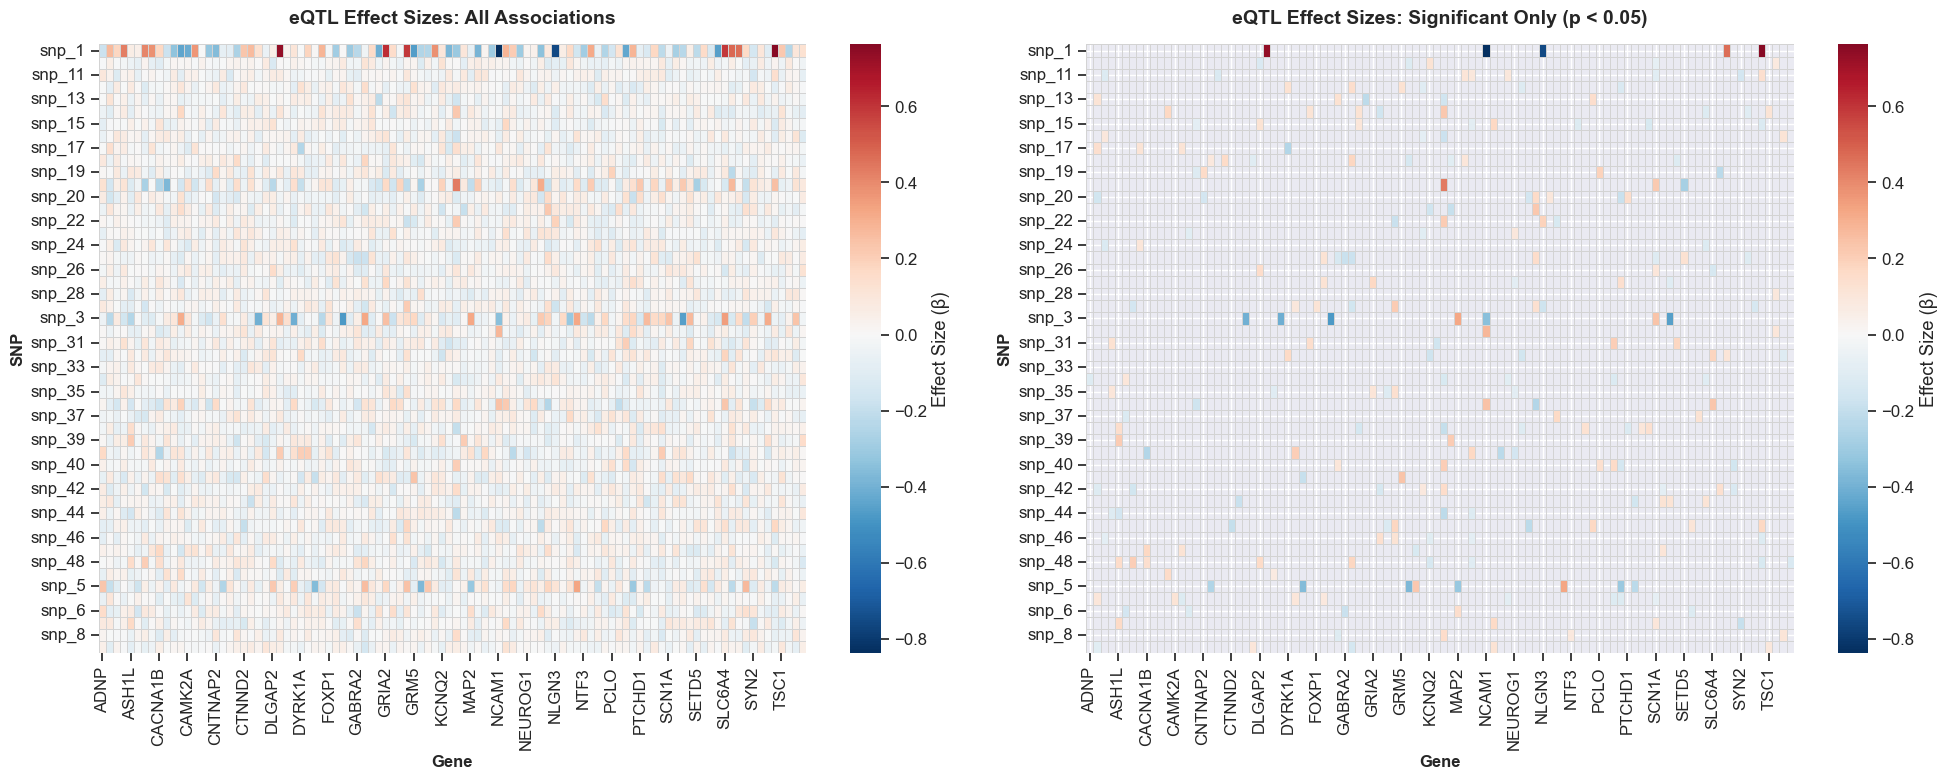


✓ eQTL effect size heatmaps generated


In [14]:
# Create effect size matrix for heatmap
effect_matrix = results_final.pivot(index='SNP', columns='Gene', values='Beta')
pval_matrix = results_final.pivot(index='SNP', columns='Gene', values='P_value')

# Create mask for non-significant associations
mask = pval_matrix > 0.05

# Create heatmap
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Heatmap 1: All effect sizes
sns.heatmap(effect_matrix, annot=False, fmt=".2f", cmap='RdBu_r', center=0,
            cbar_kws={'label': 'Effect Size (β)'}, ax=ax1,
            linewidths=0.5, linecolor='lightgray')
ax1.set_title('eQTL Effect Sizes: All Associations', fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Gene', fontsize=12, fontweight='bold')
ax1.set_ylabel('SNP', fontsize=12, fontweight='bold')

# Heatmap 2: Only significant associations
effect_matrix_masked = effect_matrix.copy()
effect_matrix_masked[mask] = np.nan
sns.heatmap(effect_matrix_masked, annot=False, fmt=".2f", cmap='RdBu_r', center=0,
            cbar_kws={'label': 'Effect Size (β)'}, ax=ax2,
            linewidths=0.5, linecolor='lightgray', 
            mask=mask, vmin=effect_matrix.min().min(), vmax=effect_matrix.max().max())
ax2.set_title('eQTL Effect Sizes: Significant Only (p < 0.05)', 
             fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel('Gene', fontsize=12, fontweight='bold')
ax2.set_ylabel('SNP', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n\u2713 eQTL effect size heatmaps generated")

### 4.4 Summary Statistics and Export Results

In [15]:
print("=" * 70)
print("FINAL SUMMARY STATISTICS")
print("=" * 70)

# Summary by gene
summary_by_gene = results_final.groupby('Gene').agg({
    'FDR_significant': 'sum',
    'P_value': 'min',
    'Beta': lambda x: x.abs().max(),
    'R_squared': 'max'
}).reset_index()
summary_by_gene.columns = ['Gene', 'N_significant_eQTLs', 'Min_pvalue', 'Max_abs_beta', 'Max_Rsquared']
summary_by_gene = summary_by_gene.sort_values('N_significant_eQTLs', ascending=False)

print("\nSummary by Gene:")
print(summary_by_gene.to_string(index=False))

# Summary by SNP
summary_by_snp = results_final.groupby('SNP').agg({
    'FDR_significant': 'sum',
    'P_value': 'min',
    'Beta': lambda x: x.abs().max(),
    'R_squared': 'max'
}).reset_index()
summary_by_snp.columns = ['SNP', 'N_genes_affected', 'Min_pvalue', 'Max_abs_beta', 'Max_Rsquared']
summary_by_snp = summary_by_snp.sort_values('N_genes_affected', ascending=False)

print("\n" + "=" * 70)
print("\nSummary by SNP:")
print(summary_by_snp.to_string(index=False))

# Overall statistics
print("\n" + "=" * 70)
print("OVERALL STATISTICS")
print("=" * 70)
print(f"Total SNP-gene pairs tested: {len(results_final):,}")
print(f"Nominally significant (p < 0.05): {results_final['Significant'].sum():,} ({results_final['Significant'].sum()/len(results_final)*100:.2f}%)")
print(f"FDR significant (q < 0.05): {results_final['FDR_significant'].sum():,} ({results_final['FDR_significant'].sum()/len(results_final)*100:.2f}%)")
print(f"Bonferroni significant: {results_final['Bonferroni_significant'].sum():,} ({results_final['Bonferroni_significant'].sum()/len(results_final)*100:.2f}%)")
print(f"\nEffect size range: [{results_final['Beta'].min():.4f}, {results_final['Beta'].max():.4f}]")
print(f"Mean |effect size|: {results_final['Beta'].abs().mean():.4f}")
print(f"Median |effect size|: {results_final['Beta'].abs().median():.4f}")
print(f"\nR² range: [{results_final['R_squared'].min():.4f}, {results_final['R_squared'].max():.4f}]")
print(f"Mean R²: {results_final['R_squared'].mean():.4f}")

# Save results to file
output_file = '../data/eqtl_results_complete.tsv'
results_final.to_csv(output_file, sep='\t', index=False)
print(f"\n\u2713 Results saved to: {output_file}")

print("\n" + "=" * 70)
print("eQTL ANALYSIS COMPLETE!")
print("=" * 70)

FINAL SUMMARY STATISTICS

Summary by Gene:
   Gene  N_significant_eQTLs  Min_pvalue  Max_abs_beta  Max_Rsquared
   ADNP                    0  4.3073e-02        0.2354        0.6264
    NGF                    0  5.5965e-03        0.2460        0.5006
   POGZ                    0  6.5048e-02        0.2017        0.5927
   PCLO                    0  1.2571e-02        0.1880        0.6046
  NTRK3                    0  2.1511e-02        0.2557        0.5563
  NTRK2                    0  3.0140e-02        0.1958        0.6036
  NTRK1                    0  3.3515e-02        0.3188        0.6249
   NTF3                    0  3.8440e-02        0.2885        0.7956
  NRXN1                    0  8.8447e-03        0.3295        0.6343
  NPAS4                    0  1.5088e-02        0.3172        0.5995
 NLGN4X                    0  4.3950e-02        0.1648        0.8003
  NLGN3                    0  5.7468e-03        0.7566        0.5406
    NF1                    0  1.9152e-03        0.3415      

---
## Conclusions and Key Takeaways

### What We Learned

1. **eQTL Fundamentals**
   - eQTLs link genetic variation to gene expression
   - Linear regression quantifies SNP effects on expression
   - Effect sizes represent change in expression per allele copy

2. **Importance of Confounders**
   - Raw expression data contains technical and biological noise
   - Covariates improve power and reduce false positives
   - PCA efficiently captures major sources of variation

3. **Multiple Testing**
   - Genome-wide studies require p-value adjustment
   - FDR methods balance sensitivity and specificity
   - Bonferroni is conservative but guarantees control

4. **Interpretation**
   - Statistical significance ≠ biological importance
   - Effect sizes and R² indicate practical relevance
   - Visualization aids interpretation and communication

### Next Steps

- **Replication**: Validate findings in independent cohorts
- **Functional Analysis**: Investigate mechanisms of top eQTLs
- **Integration**: Combine with GWAS for disease insights
- **Advanced Methods**: Explore trans-eQTLs, interaction effects, and causal inference
- **Run MatrixEQTL**: Run MatrixEQTL on same ASD Dataset


### Resources

- **GTEx Consortium**: [gtexportal.org](https://gtexportal.org)
- **eQTL Catalogue**: [ebi.ac.uk/eqtl](https://www.ebi.ac.uk/eqtl)
- **Tools**: MatrixEQTL, FastQTL, tensorQTL

---

**Tutorial completed successfully!** This notebook has introduced the fundamental concepts and practical methods for eQTL analysis using Python.